# Demand attribution method 2 - HadGEM model based method
factual vs counterfactual dataset

In [1]:
# Import packages
import xarray as xr
import numpy as np
import pandas as pd

In [ ]:
# Import the data that will be needed

# bias corrected JJA HadGEM factual dataset "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_qm_pergrid.nc"
# bias corrected JJA HadGEM counterfactual dataset "/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug_qm_pergrid.nc"

# Preprocessed OBS longterm dataset: "/home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc"
# bias corrected model longterm HadGEM data: "/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_358.nc"

In [2]:
pip install Fitter

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Step 0 data consistency between 2 methods

In [ ]:
# Getting the regridded observed data (CN05 regrid to HadGEM resolution, so that the sum CDD is comparable)
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd

# ============================================================
# USER PATHS
# ============================================================

monthly_cdd_path = "/home/users/weijia_6/Yangtze_code/demand_data/monthly_CDD_1961_2022.nc"
pop_path = "/home/users/weijia_6/Yangtze_code/ssp2_2020.nc"
hadgem_ref_path = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_qm_pergrid.nc"
shp_path = "/home/users/weijia_6/Yangtze_code/geoBoundaries-CHN-ADM1-all/geoBoundaries-CHN-ADM1.shp"

out_monthly_csv = "/home/users/weijia_6/Yangtze_code/popweighted_monthly_CDD_1961_2022_regridded_to_hadgem.csv"
out_jja_csv     = "/home/users/weijia_6/Yangtze_code/popweighted_CDD_summer_sum_1961_2022_regridded_to_hadgem.csv"

# monthly_cdd_path = "/home/users/weijia_6/Yangtze_code/demand_data/monthly_CDD_1961_2022.nc"
# pop_path = "/home/users/weijia_6/Yangtze_code/ssp2_2020.nc"
# hadgem_ref_path = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_qm_pergrid.nc"
# shp_path = "/home/users/weijia_6/Yangtze_code/demand_data/审图号：GS（2024）0650号/中国_省.shp"

# out_monthly_csv = "/home/users/weijia_6/Yangtze_code/demand_data/popweighted_monthly_CDD_1961_2022_regridded_to_hadgem.csv"
# out_jja_csv     = "/home/users/weijia_6/Yangtze_code/demand_data/popweighted_CDD_summer_sum_1961_2022_regridded_to_hadgem.csv"

# ============================================================
# LOAD DATA
# ============================================================

ds_cdd = xr.open_dataset(monthly_cdd_path)
ds_pop = xr.open_dataset(pop_path)
ds_ref = xr.open_dataset(hadgem_ref_path)

cdd = ds_cdd["monthly_cdd"]    # dims: time, lat, lon
pop = ds_pop["ssp2_2020"]      # dims: lat, lon

# Detect coordinate names
lat_name = [c for c in cdd.coords if "lat" in c.lower()][0]
lon_name = [c for c in cdd.coords if "lon" in c.lower()][0]

ref_lat = ds_ref[[c for c in ds_ref.coords if "lat" in c.lower()][0]].values
ref_lon = ds_ref[[c for c in ds_ref.coords if "lon" in c.lower()][0]].values

# ============================================================
# REGRID CDD + POPULATION TO HADGEM GRID
# ============================================================

cdd_regrid = cdd.interp({lat_name: ref_lat, lon_name: ref_lon}, method="linear")
pop_regrid = pop.interp({lat_name: ref_lat, lon_name: ref_lon}, method="linear")

# Clean population
pop_regrid = pop_regrid.where((pop_regrid > 0) & (pop_regrid < 1e10))

# ============================================================
# LOAD PROVINCE SHAPEFILE
# ============================================================

gdf = gpd.read_file(shp_path).to_crs("EPSG:4326")

province_col = "shapeName"
province_names = gdf[province_col].tolist()

# Build grid of points
lon2d, lat2d = np.meshgrid(ref_lon, ref_lat)
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
    crs="EPSG:4326"
)

# Spatial join: assign each grid cell to a province
joined = gpd.sjoin(points, gdf[[province_col, "geometry"]], how="left", predicate="within")

# FIX: convert ArrowStringArray → NumPy array
province_grid = np.array(joined[province_col].astype(str)).reshape(lat2d.shape)


# ============================================================
# POPULATION-WEIGHTED MONTHLY CDD PER PROVINCE
# ============================================================

monthly_results = {}

for prov in province_names:
    print("Processing:", prov)

    mask = xr.DataArray(
        (province_grid == prov),
        coords={lat_name: ref_lat, lon_name: ref_lon},
        dims=(lat_name, lon_name)
    )

    # Weighted sum over space
    weighted = (cdd_regrid * pop_regrid * mask).sum(dim=[lat_name, lon_name], skipna=True)

    # Total population
    total_pop = (pop_regrid * mask).sum(dim=[lat_name, lon_name], skipna=True)

    # Population-weighted monthly CDD
    pw = (weighted / total_pop).values

    monthly_results[prov] = pw

# Save monthly CSV
df_monthly = pd.DataFrame(monthly_results, index=pd.Index(cdd_regrid["time"].values, name="time")).T
df_monthly.to_csv(out_monthly_csv)
print("Saved monthly:", out_monthly_csv)

# ============================================================
# COMPUTE JJA SUM (June, July, August)
# ============================================================

years = np.arange(1961, 2023)
months_of_interest = [6, 7, 8]

df_jja = pd.DataFrame(index=province_names, columns=years)

for prov in province_names:
    monthly_vals = df_monthly.loc[prov].values  # length = 744 months

    for year in years:
        start_month = (year - 1961) * 12
        idx = [start_month + m - 1 for m in months_of_interest]
        df_jja.loc[prov, year] = np.sum(monthly_vals[idx])

# Save JJA CSV
df_jja.to_csv(out_jja_csv)
print("Saved JJA:", out_jja_csv)

print(df_jja.iloc[:5, :5])



## Step 1 Fit function to the large ensemble dataset

In [2]:
# Fit function to the large ensemble dataset

Using provinces: ['Guizhou Province', 'Sichuan Province', 'Hunan Province', 'Hubei Province', 'Chongqing Municipality']
Samples per province: 525

Fitting Guizhou Province__factual ...


2026-08-09 16:07:16.125 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=0.006321, AIC=3829.84, KS=0.0487
2026-08-09 16:07:16.126 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted logistic: error=0.006205, AIC=3826.54, KS=0.0362
2026-08-09 16:07:16.127 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=0.005042, AIC=3800.04, KS=0.0182
2026-08-09 16:07:16.136 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=0.005085, AIC=3801.22, KS=0.0195
2026-08-09 16:07:16.145 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted weibull_min: error=0.005173, AIC=inf, KS=0.0231
2026-08-09 16:07:16.175 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted pearson3: error=0.005085, AIC=3801.22, KS=0.0195
2026-08-09 16:07:16.183 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted genextreme: error=0.005005, AIC=3799.64, KS=0.0173
2026-08-09 16:07:16.194 | INFO     | fitt


Fitting Guizhou Province__counterfactual ...


2026-08-09 16:07:17.722 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=0.033271, AIC=2981.54, KS=0.0216
2026-08-09 16:07:17.725 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=0.032995, AIC=2979.32, KS=0.0192
2026-08-09 16:07:17.730 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted weibull_min: error=0.033170, AIC=inf, KS=0.0187
2026-08-09 16:07:17.743 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted pearson3: error=0.032995, AIC=2979.32, KS=0.0192
2026-08-09 16:07:17.762 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted genextreme: error=0.033376, AIC=2981.10, KS=0.0232
2026-08-09 16:07:17.780 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=0.001082, AIC=4811.57, KS=0.0481
2026-08-09 16:07:17.781 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=0.000938, AIC=4791.37, KS=0.0272
2026-08-09 16:07:17.781 | INFO     | fitte


Fitting Sichuan Province__factual ...

Fitting Sichuan Province__counterfactual ...


...

,mean_rank_sse,median_rank_sse,mean_sse,median_sse,win_count
distribution,,,,,
genextreme,2.1,2.0,0.004561,0.000947,4.0
gamma,2.6,3.0,0.004533,0.000951,1.0
lognorm,2.9,3.0,0.004556,0.000946,3.0
pearson3,3.4,3.5,0.004533,0.000951,0.0
weibull_min,4.0,5.0,0.004578,0.000961,2.0
logistic,6.4,6.0,0.005455,0.001064,0.0
norm,6.6,7.0,0.005585,0.001061,0.0


,dataset,best_distribution
64,Chongqing Municipality__counterfactual,genextreme
59,Chongqing Municipality__factual,lognorm
7,Guizhou Province__counterfactual,gamma
1,Guizhou Province__factual,genextreme
55,Hubei Province__counterfactual,weibull_min
48,Hubei Province__factual,weibull_min
36,Hunan Province__counterfactual,genextreme
29,Hunan Province__factual,genextreme
24,Sichuan Province__counterfactual,lognorm
17,Sichuan Province__factual,lognorm



Province: Guizhou Province
  fitting factual with shared family: genextreme
  fitting counterfactual with shared family: genextreme

Province: Sichuan Province
  fitting factual with shared family: genextreme
  fitting counterfactual with shared family: genextreme

Province: Hunan Province
  fitting factual with shared family: genextreme
  fitting counterfactual with shared family: genextreme

Province: Hubei Province
  fitting factual with shared family: genextreme
  fitting counterfactual with shared family: genextreme

Province: Chongqing Municipality
  fitting factual with shared family: genextreme
  fitting counterfactual with shared family: genextreme

Saved:
 - /home/users/weijia_6/Yangtze_code/demand_result/best_fit_summary_shared_family.csv
 - /home/users/weijia_6/Yangtze_code/demand_result/fit_store_shared_family.pkl


,Province,shared_family_used,factual_params,counterfactual_params
0,Guizhou Province,genextreme,"(np.float64(0.11328060180023392), np.float64(3...","(np.float64(0.09027415855078577), np.float64(1..."
1,Sichuan Province,genextreme,"(np.float64(0.13983045631210766), np.float64(8...","(np.float64(0.07752879582833883), np.float64(4..."
2,Hunan Province,genextreme,"(np.float64(0.21629484387168713), np.float64(1...","(np.float64(0.12878357635470689), np.float64(1..."
3,Hubei Province,genextreme,"(np.float64(0.16778892737168216), np.float64(1...","(np.float64(0.15930319527691525), np.float64(9..."
4,Chongqing Municipality,genextreme,"(np.float64(0.14365543034282607), np.float64(1...","(np.float64(0.08994869085998972), np.float64(6..."


Saved diagnostic figure to: /home/users/weijia_6/Yangtze_code/demand_result/fit_confirmation_shared_family.png


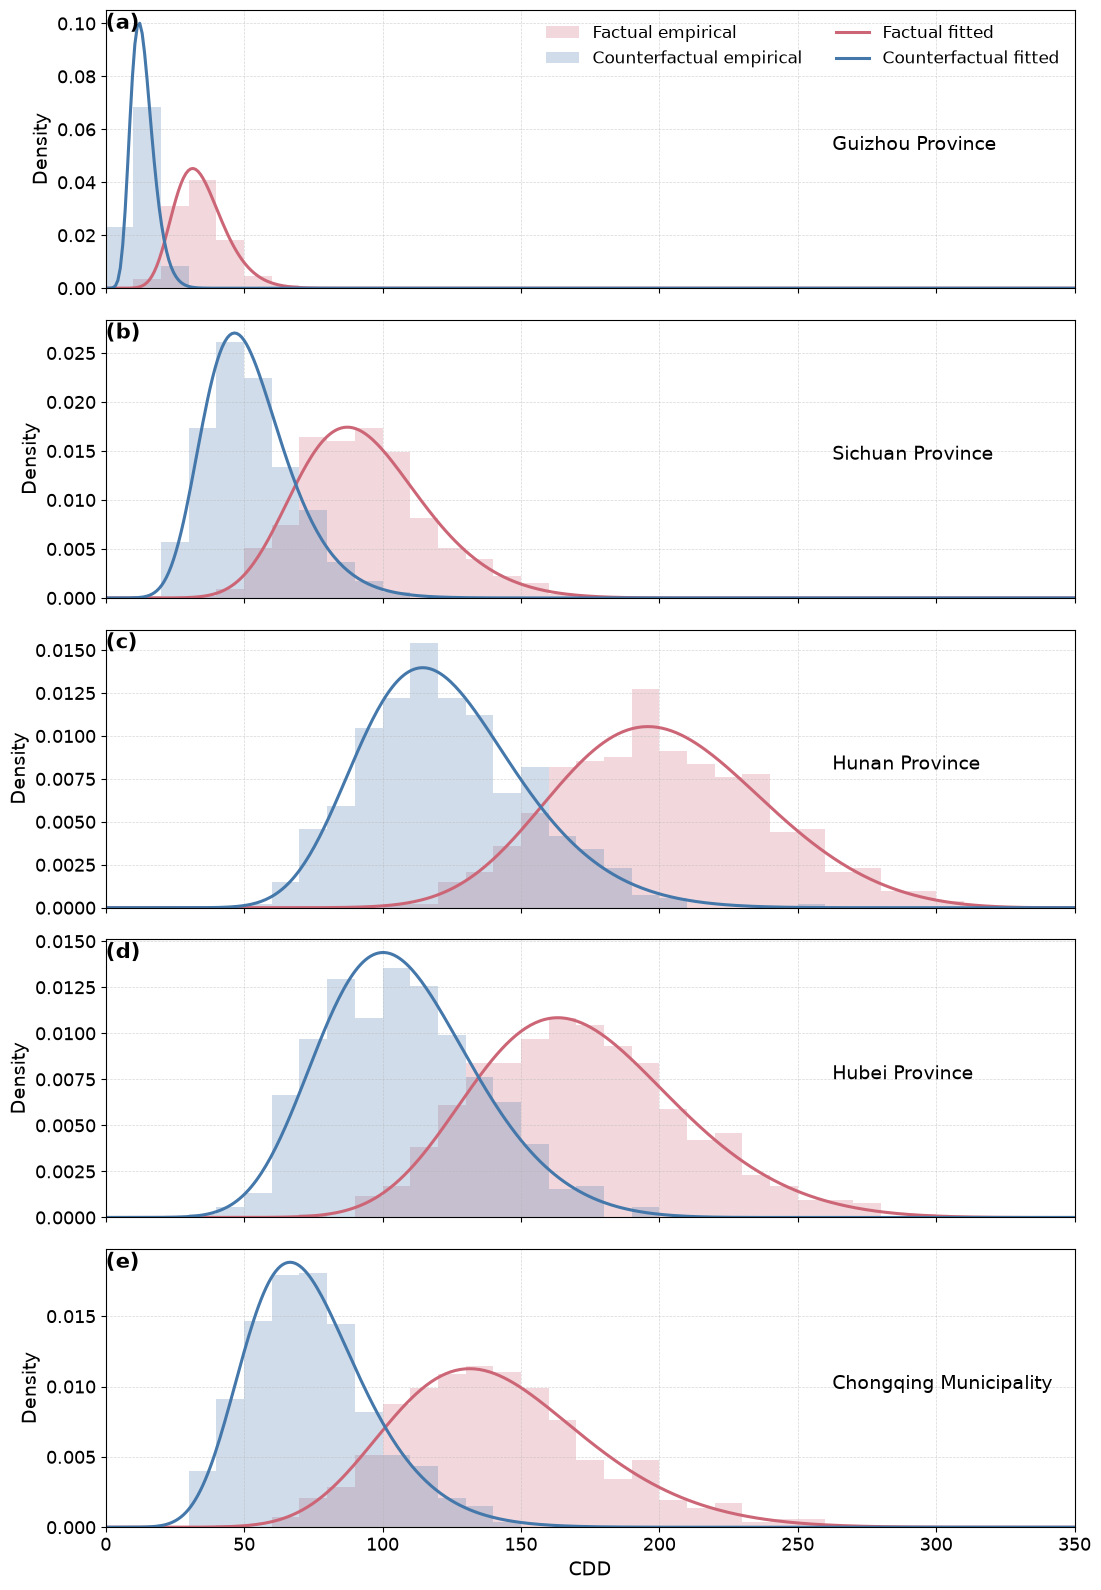

In [13]:
# The shared fit function type is selected by the best average rank of sumsquare_error across all 10 datasets

import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from fitter import Fitter
from IPython.display import display

# ---------------- USER INPUTS ----------------
factual_csv = "/home/users/weijia_6/Yangtze_code/CDD26_factual_popweighted_provinces_correct.csv"
counterfactual_csv = "/home/users/weijia_6/Yangtze_code/CDD26_counterfactual_popweighted_provinces_correct.csv"

selected_provinces = [
    "Guizhou Province",
    "Sichuan Province",
    "Hunan Province",
    "Hubei Province",
    "Chongqing Municipality"
]

# Output folder
out_dir = Path("/home/users/weijia_6/Yangtze_code/demand_result")
out_dir.mkdir(parents=True, exist_ok=True)

# Candidate distributions to test
candidate_distributions = [
    "gamma",
    "lognorm",
    "pearson3",
    "weibull_min",
    "genextreme",
    "logistic",
    "norm"
]

fit_metric = "sumsquare_error"
fit_timeout = 600

# ---------------- HELPER FUNCTIONS ----------------
def load_province_sample_csv(path):
    df_raw = pd.read_csv(path, header=0, dtype=str)
    df_raw.columns = [c.strip() for c in df_raw.columns]

    def frac_numeric(series):
        return pd.to_numeric(series, errors="coerce").notna().mean()

    numeric_threshold = 0.95
    col_scores = {col: frac_numeric(df_raw[col]) for col in df_raw.columns}
    province_candidates = [c for c, score in col_scores.items() if score < numeric_threshold]

    if not province_candidates:
        province_col = df_raw.columns[0]
    else:
        province_col = sorted(province_candidates, key=lambda c: col_scores[c])[0]

    sample_cols = [c for c in df_raw.columns if c != province_col]
    sample_df = df_raw[sample_cols].apply(pd.to_numeric, errors="coerce")
    sample_df = sample_df.loc[:, sample_df.notna().any(axis=0)]

    provinces = df_raw[province_col].astype(str).str.strip().values
    result = pd.DataFrame(
        sample_df.values,
        index=provinces,
        columns=[f"sample_{i}" for i in range(sample_df.shape[1])]
    )
    return result.astype(float)

def clean_data(arr):
    a = np.asarray(arr, dtype=float)
    return a[np.isfinite(a)]

def fit_best_family_with_fitter(data, distributions, fit_metric="sumsquare_error", timeout=600):
    data = clean_data(data)
    f = Fitter(data, distributions=distributions, timeout=timeout)
    f.fit()
    best_dict = f.get_best(method=fit_metric)
    best_name = next(iter(best_dict.keys()))
    best_params = best_dict[best_name]
    return f, best_name, best_params

def extract_fit_table(fitter_obj, dataset_name):
    """
    Robustly extract the fit table from fitter.
    Works with fitter.df_errors when available; otherwise falls back to summary().
    """
    if hasattr(fitter_obj, "df_errors") and fitter_obj.df_errors is not None:
        tbl = fitter_obj.df_errors.copy()
    else:
        tbl = fitter_obj.summary()

    if not isinstance(tbl, pd.DataFrame):
        tbl = pd.DataFrame(tbl)

    tbl = tbl.reset_index()

    if "index" in tbl.columns and "distribution" not in tbl.columns:
        tbl = tbl.rename(columns={"index": "distribution"})

    # Standardize column names
    tbl.columns = [str(c).strip().lower() for c in tbl.columns]

    if "distribution" not in tbl.columns:
        tbl = tbl.rename(columns={tbl.columns[0]: "distribution"})

    tbl["dataset"] = dataset_name
    return tbl

def make_frozen_dist(dist_name, params):
    dist_obj = getattr(stats, dist_name)
    return dist_obj(*params)

# ---------------- LOAD DATA ----------------
if not os.path.exists(factual_csv) or not os.path.exists(counterfactual_csv):
    raise FileNotFoundError("Missing one of the CSV files. Please check the paths.")

df_f = load_province_sample_csv(factual_csv)
df_c = load_province_sample_csv(counterfactual_csv)

common_provs = sorted(set(df_f.index).intersection(df_c.index))
selected = [p for p in selected_provinces if p in common_provs]

if len(selected) == 0:
    raise RuntimeError("None of the selected provinces were found in both files.")

df_f = df_f.loc[selected]
df_c = df_c.loc[selected]

print("Using provinces:", selected)
print("Samples per province:", df_f.shape[1])

# ---------------- STEP 1: FIT ALL 10 DATASETS ----------------
fit_tables = []
dataset_fit_objects = {}

for prov in selected:
    for scenario in ["factual", "counterfactual"]:
        dataset_name = f"{prov}__{scenario}"
        data = clean_data(df_f.loc[prov].values) if scenario == "factual" else clean_data(df_c.loc[prov].values)

        print(f"\nFitting {dataset_name} ...")
        fitter_obj = Fitter(data, distributions=candidate_distributions, timeout=fit_timeout)
        fitter_obj.fit()

        table = extract_fit_table(fitter_obj, dataset_name)

        # Keep only the columns we need for model selection, but preserve all if present
        needed_cols = ["dataset", "distribution", fit_metric]
        if fit_metric not in table.columns:
            raise KeyError(f"Expected metric column '{fit_metric}' not found in fitter output.")

        # Store the fitted object and the table
        dataset_fit_objects[dataset_name] = {
            "data": data,
            "fitter": fitter_obj,
            "fit_table": table
        }
        fit_tables.append(table)

# Combine all fit tables
all_fit_df = pd.concat(fit_tables, ignore_index=True)

# Normalize metric column name for convenience
all_fit_df = all_fit_df.rename(columns={fit_metric: "sumsquare_error"})

# ---------------- STEP 2: CHOOSE ONE COMMON FAMILY USING ALL 10 DATASETS ----------------
# Rank within each dataset: smaller SSE = better rank
all_fit_df["rank_sse"] = all_fit_df.groupby("dataset")["sumsquare_error"].rank(method="min", ascending=True)

# Count how often each distribution wins outright
best_by_dataset = (
    all_fit_df.loc[all_fit_df.groupby("dataset")["sumsquare_error"].idxmin(), ["dataset", "distribution"]]
    .rename(columns={"distribution": "best_distribution"})
)

winner_counts = best_by_dataset["best_distribution"].value_counts().rename("win_count")

shared_summary = (
    all_fit_df.groupby("distribution")
    .agg(
        mean_rank_sse=("rank_sse", "mean"),
        median_rank_sse=("rank_sse", "median"),
        mean_sse=("sumsquare_error", "mean"),
        median_sse=("sumsquare_error", "median"),
    )
    .join(winner_counts, how="left")
    .fillna({"win_count": 0})
    .sort_values(["mean_rank_sse", "mean_sse", "median_sse"], ascending=True)
)

shared_family = shared_summary.index[0]
print("\nSelected shared family across all 10 datasets:", shared_family)

# Save model selection tables
all_fit_df.to_csv(out_dir / "all_fit_tables_10datasets.csv", index=False)
shared_summary.to_csv(out_dir / "shared_family_ranking.csv")
best_by_dataset.to_csv(out_dir / "best_distribution_by_dataset.csv", index=False)

print("\nSaved:")
print(" -", out_dir / "all_fit_tables_10datasets.csv")
print(" -", out_dir / "shared_family_ranking.csv")
print(" -", out_dir / "best_distribution_by_dataset.csv")

display(shared_summary)
display(best_by_dataset)

# ---------------- STEP 3: REFIT ALL 10 DATASETS USING THE SAME FAMILY ----------------
dist_family = getattr(stats, shared_family)

fit_store = {}
summary_rows = []

for prov in selected:
    factual_vals = clean_data(df_f.loc[prov].values)
    cf_vals = clean_data(df_c.loc[prov].values)

    print(f"\nProvince: {prov}")
    print(f"  fitting factual with shared family: {shared_family}")
    params_f = dist_family.fit(factual_vals)
    dist_f = dist_family(*params_f)

    print(f"  fitting counterfactual with shared family: {shared_family}")
    params_cf = dist_family.fit(cf_vals)
    dist_cf = dist_family(*params_cf)

    fit_store[prov] = {
        "shared_family": shared_family,
        "factual": {
            "data": factual_vals,
            "params": params_f,
            "dist": dist_f,
        },
        "counterfactual": {
            "data": cf_vals,
            "params": params_cf,
            "dist": dist_cf,
        }
    }

    summary_rows.append({
        "Province": prov,
        "shared_family_used": shared_family,
        "factual_params": repr(params_f),
        "counterfactual_params": repr(params_cf),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(out_dir / "best_fit_summary_shared_family.csv", index=False)

with open(out_dir / "fit_store_shared_family.pkl", "wb") as f:
    pickle.dump(fit_store, f)

print("\nSaved:")
print(" -", out_dir / "best_fit_summary_shared_family.csv")
print(" -", out_dir / "fit_store_shared_family.pkl")

display(summary_df)

# ---------------- DIAGNOSTIC FIGURE ----------------
# One subplot per province, factual = orange/red, counterfactual = blue
FACTUAL_COLOR = "#CC6677"
COUNTER_COLOR = "#4477AA"

n = len(selected)
fig, axes = plt.subplots(n, 1, figsize=(11, 3.2 * n), sharex=True)

if n == 1:
    axes = [axes]

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]


for i, prov in enumerate(selected):
    ax = axes[i]

    factual_vals = fit_store[prov]["factual"]["data"]
    cf_vals = fit_store[prov]["counterfactual"]["data"]

    dist_f = fit_store[prov]["factual"]["dist"]
    dist_cf = fit_store[prov]["counterfactual"]["dist"]

    # Panel label
    ax.text(
        0.00, 0.99,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # Province name
    ax.text(
        0.75, 0.55,
        prov,
        transform=ax.transAxes,
        fontsize=14,
        va="top",
        ha="left"
    )

    # Common x-range for comparison
    x_grid = np.linspace(0, 350, 400)
    bins = np.arange(0, 351, 10)

    # Histograms
    ax.hist(
        factual_vals,
        bins=bins,
        density=True,
        alpha=0.25,
        color=FACTUAL_COLOR,
        edgecolor="none",
        label="Factual empirical"
    )
    ax.hist(
        cf_vals,
        bins=bins,
        density=True,
        alpha=0.25,
        color=COUNTER_COLOR,
        edgecolor="none",
        label="Counterfactual empirical"
    )

    # Fitted PDFs
    ax.plot(
        x_grid,
        dist_f.pdf(x_grid),
        color=FACTUAL_COLOR,
        linewidth=2.2,
        label="Factual fitted"
    )
    ax.plot(
        x_grid,
        dist_cf.pdf(x_grid),
        color=COUNTER_COLOR,
        linewidth=2.2,
        label="Counterfactual fitted"
    )

    ax.set_xlim(0, 350)
    ax.set_ylabel("Density", fontsize=14)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    if i == n - 1:
        ax.set_xlabel("CDD", fontsize=14)

    if i == 0:
        ax.legend(frameon=False, fontsize=12, ncol=2)


plt.tight_layout()
plt.savefig(out_dir / "fit_confirmation_shared_family.png", dpi=300, bbox_inches="tight")
print("Saved diagnostic figure to:", out_dir / "fit_confirmation_shared_family.png")
plt.show()
plt.close(fig)


2022 event CDD values:
Guizhou Province: 38.268
Sichuan Province: 218.997
Hunan Province: 278.939
Hubei Province: 272.689
Chongqing Municipality: 281.406


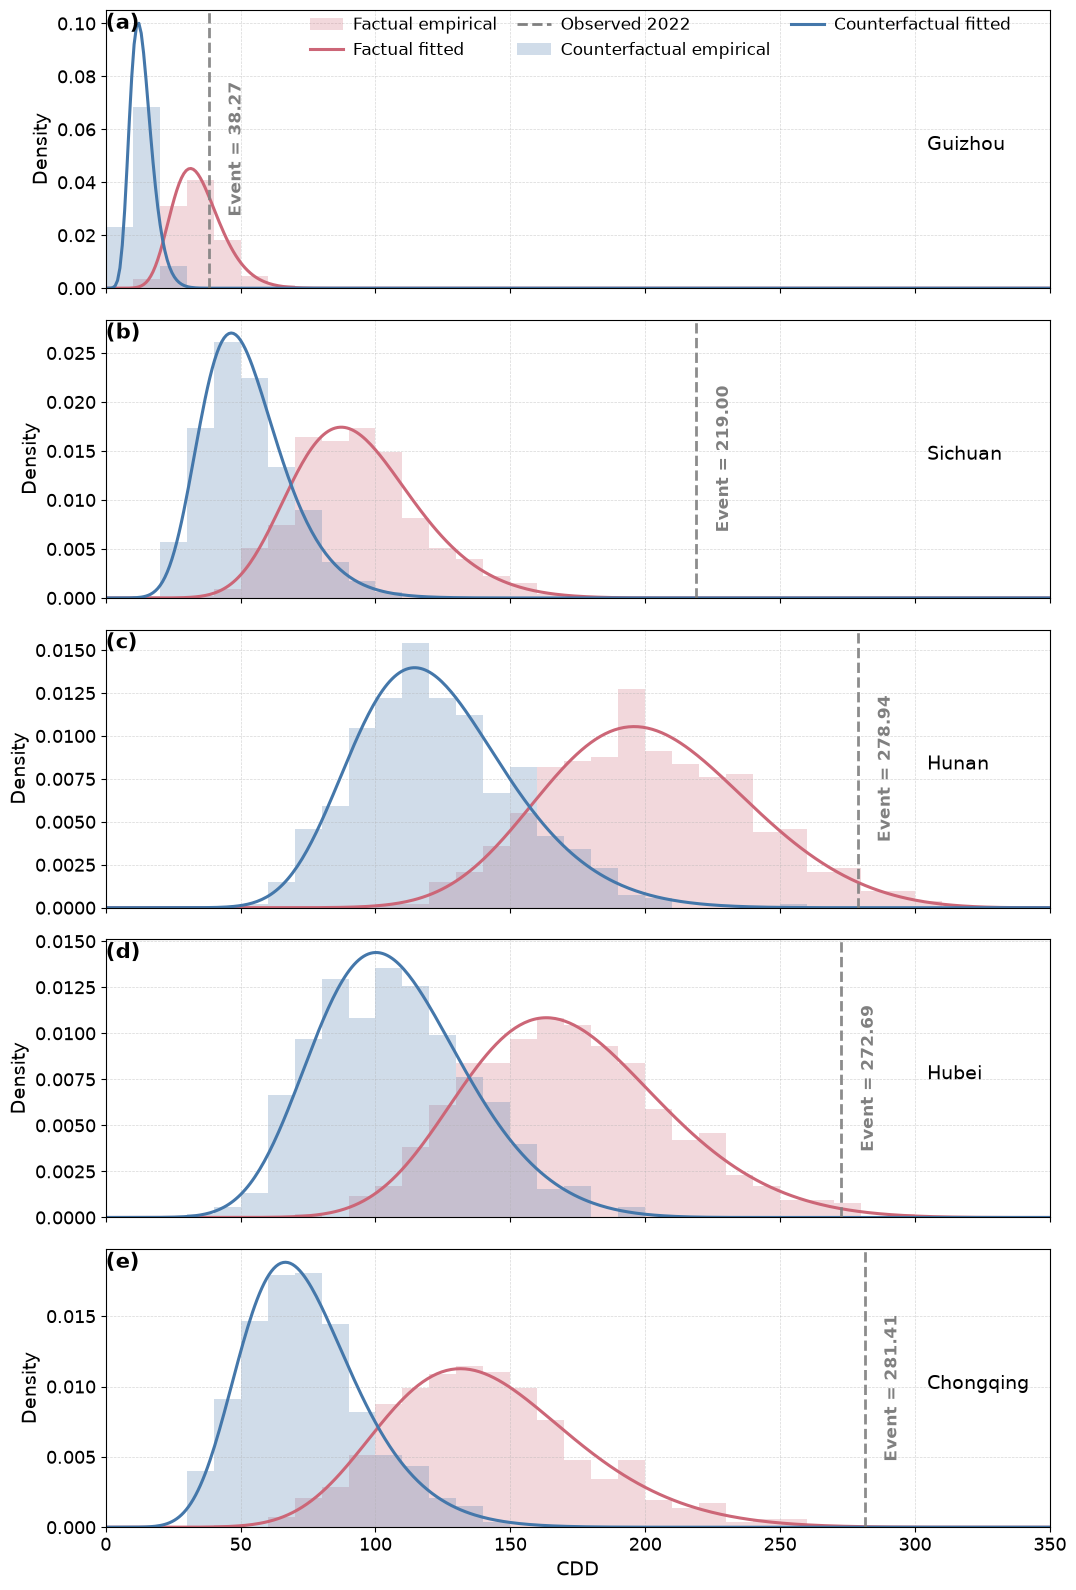

In [14]:
# ============================================================
# Load 2022 event threshold values from your CSV
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

cdd_csv = "/home/users/weijia_6/Yangtze_code/popweighted_CDD_summer_sum_1961_2022_regridded_to_hadgem.csv"

df_event = pd.read_csv(cdd_csv, index_col=0)
df_event.index = df_event.index.str.strip()

# Long names used in fit_store AND in your new CSV
selected_provinces = [
    "Guizhou Province",
    "Sichuan Province",
    "Hunan Province",
    "Hubei Province",
    "Chongqing Municipality",
]

# Extract 2022 event values
event_2022 = {
    prov: float(df_event.loc[prov, "2022"])
    for prov in selected_provinces
}

print("2022 event CDD values:")
for prov, val in event_2022.items():
    print(f"{prov}: {val:.3f}")


# ============================================================
# Updated diagnostic figure with threshold lines and labels
# ============================================================

FACTUAL_COLOR = "#CC6677"
COUNTER_COLOR = "#4477AA"
EVENT_COLOR = "grey"

n = len(selected_provinces)
fig, axes = plt.subplots(n, 1, figsize=(11, 3.2 * n), sharex=True)

if n == 1:
    axes = [axes]

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

# Short names ONLY for display
short_names = {
    "Guizhou Province": "Guizhou",
    "Sichuan Province": "Sichuan",
    "Hunan Province": "Hunan",
    "Hubei Province": "Hubei",
    "Chongqing Municipality": "Chongqing",
}

for i, prov in enumerate(selected_provinces):
    ax = axes[i]

    factual_vals = fit_store[prov]["factual"]["data"]
    cf_vals = fit_store[prov]["counterfactual"]["data"]

    dist_f = fit_store[prov]["factual"]["dist"]
    dist_cf = fit_store[prov]["counterfactual"]["dist"]

    # Panel label
    ax.text(
        0.00, 0.99, panel_labels[i],
        transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="top", ha="left"
    )

    # Province name (SHORT VERSION)
    ax.text(
        0.87, 0.55,
        short_names[prov],
        transform=ax.transAxes,
        fontsize=14,
        va="top",
        ha="left"
    )

    x_grid = np.linspace(0, 350, 400)
    bins = np.arange(0, 351, 10)

    # Histograms
    ax.hist(
        factual_vals, bins=bins, density=True, alpha=0.25,
        color=FACTUAL_COLOR, edgecolor="none", label="Factual empirical"
    )
    ax.hist(
        cf_vals, bins=bins, density=True, alpha=0.25,
        color=COUNTER_COLOR, edgecolor="none", label="Counterfactual empirical"
    )

    # Fitted PDFs
    ax.plot(
        x_grid, dist_f.pdf(x_grid),
        color=FACTUAL_COLOR, linewidth=2.2, label="Factual fitted"
    )
    ax.plot(
        x_grid, dist_cf.pdf(x_grid),
        color=COUNTER_COLOR, linewidth=2.2, label="Counterfactual fitted"
    )

    # Vertical threshold line
    thr = event_2022[prov]
    ax.axvline(
        thr,
        color=EVENT_COLOR,
        linestyle="--",
        linewidth=2.0,
        alpha=0.9,
    )

    ax.set_xlim(0, 350)

    # Event label to the right of the threshold line, vertical
    y_top = ax.get_ylim()[1]
    x_offset = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])

    ax.text(
        thr + x_offset,
        y_top * 0.5,
        f"Event = {thr:.2f}",
        rotation=90,
        fontsize=12,
        color=EVENT_COLOR,
        va="center",
        ha="left",
        fontweight="bold",
    )

    ax.set_ylabel("Density", fontsize=14)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    if i == n - 1:
        ax.set_xlabel("CDD", fontsize=14)

    if i == 0:
        # Legend style matched to the hydro figure
        legend_handles = [
            Patch(facecolor=FACTUAL_COLOR, alpha=0.25, edgecolor="none", label="Factual empirical"),
            Line2D([0], [0], color=FACTUAL_COLOR, linewidth=2.2, label="Factual fitted"),
            Line2D([0], [0], color=EVENT_COLOR, linestyle="--", linewidth=2.0, label="Observed 2022"),
            Patch(facecolor=COUNTER_COLOR, alpha=0.25, edgecolor="none", label="Counterfactual empirical"),
            Line2D([0], [0], color=COUNTER_COLOR, linewidth=2.2, label="Counterfactual fitted"),
        ]

        ax.legend(
            handles=legend_handles,
            frameon=False,
            fontsize=12,
            ncol=3,
            loc="upper left",
            bbox_to_anchor=(0.2, 1.03),
            handlelength=2.0,
            columnspacing=1.2,
            handletextpad=0.6,
        )

plt.tight_layout()
plt.savefig(
    out_dir / "fit_confirmation_shared_family_with_threshold.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

2022 event CDD values:
Guizhou Province: 38.268
Sichuan Province: 218.997
Hunan Province: 278.939
Hubei Province: 272.689
Chongqing Municipality: 281.406

Selected percentile thresholds:
Guizhou Province: percentile=10.0%, threshold=23.706
Sichuan Province: percentile=55.0%, threshold=94.752
Hunan Province: percentile=45.0%, threshold=194.391
Hubei Province: percentile=55.0%, threshold=173.736
Chongqing Municipality: percentile=45.0%, threshold=133.575


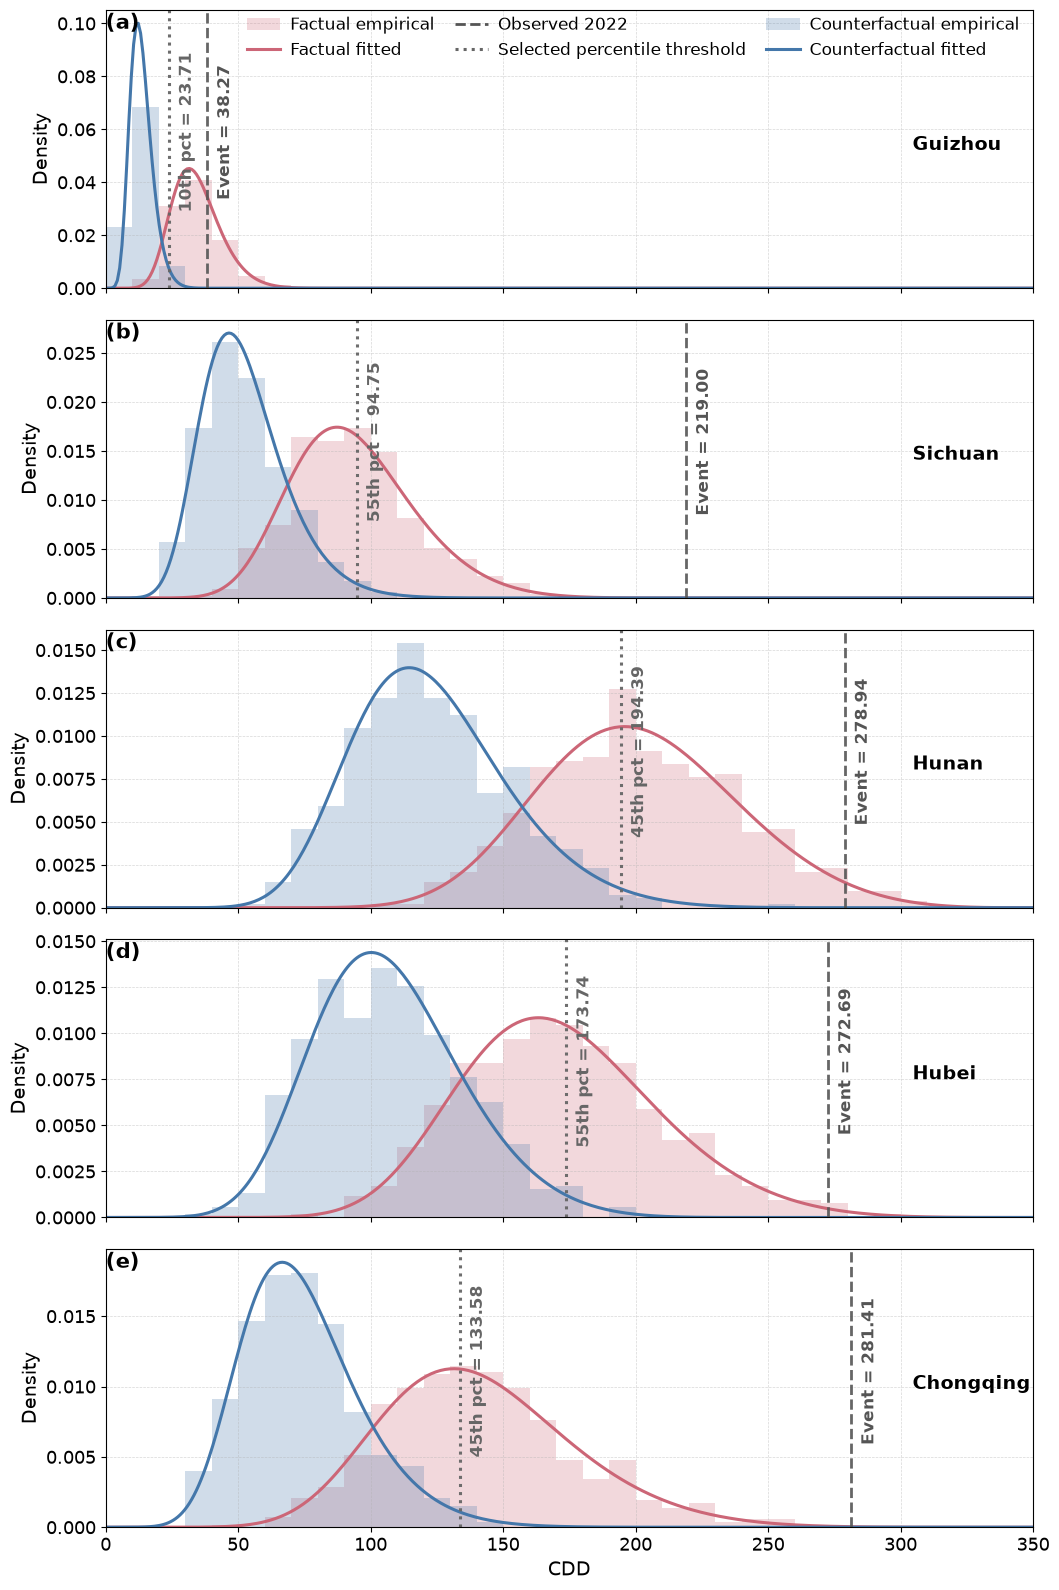

In [15]:
# Distribution comparison, event threshold, percentile threshold

# ============================================================
# Load 2022 event threshold values and selected percentile thresholds
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

cdd_csv = "/home/users/weijia_6/Yangtze_code/popweighted_CDD_summer_sum_1961_2022_regridded_to_hadgem.csv"

df_event = pd.read_csv(cdd_csv, index_col=0)
df_event.index = df_event.index.str.strip()

# Long names used in fit_store AND in your new CSV
selected_provinces = [
    "Guizhou Province",
    "Sichuan Province",
    "Hunan Province",
    "Hubei Province",
    "Chongqing Municipality",
]

# Extract 2022 observed event values
event_2022 = {
    prov: float(df_event.loc[prov, "2022"])
    for prov in selected_provinces
}

print("2022 event CDD values:")
for prov, val in event_2022.items():
    print(f"{prov}: {val:.3f}")

# Selected percentile thresholds from your attribution step
selected_percentile = {
    "Sichuan Province": 55.0,
    "Chongqing Municipality": 45.0,
    "Hubei Province": 55.0,
    "Hunan Province": 45.0,
    "Guizhou Province": 10.0,
}

event_threshold_cdd = {
    "Sichuan Province": 94.7525 ,
    "Chongqing Municipality": 133.5753,
    "Hubei Province": 173.7357,
    "Hunan Province": 194.3906,
    "Guizhou Province": 23.7060,
}



print("\nSelected percentile thresholds:")
for prov in selected_provinces:
    print(
        f"{prov}: percentile={selected_percentile[prov]:.1f}%, "
        f"threshold={event_threshold_cdd[prov]:.3f}"
    )


# ============================================================
# Diagnostic figure with both thresholds
# ============================================================

FACTUAL_COLOR = "#CC6677"
COUNTER_COLOR = "#4477AA"
EVENT_COLOR = "#555555"
ATTR_COLOR = "#666666"

n = len(selected_provinces)
fig, axes = plt.subplots(n, 1, figsize=(11, 3.2 * n), sharex=True)

if n == 1:
    axes = [axes]

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

# Short names ONLY for display
short_names = {
    "Guizhou Province": "Guizhou",
    "Sichuan Province": "Sichuan",
    "Hunan Province": "Hunan",
    "Hubei Province": "Hubei",
    "Chongqing Municipality": "Chongqing",
}

for i, prov in enumerate(selected_provinces):
    ax = axes[i]

    factual_vals = fit_store[prov]["factual"]["data"]
    cf_vals = fit_store[prov]["counterfactual"]["data"]

    dist_f = fit_store[prov]["factual"]["dist"]
    dist_cf = fit_store[prov]["counterfactual"]["dist"]

    # Panel label
    ax.text(
        0.00, 0.99, panel_labels[i],
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # Province name (SHORT VERSION)
    ax.text(
        0.87, 0.55,
        short_names[prov],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

    x_grid = np.linspace(0, 350, 400)
    bins = np.arange(0, 351, 10)

    # Histograms
    ax.hist(
        factual_vals, bins=bins, density=True, alpha=0.25,
        color=FACTUAL_COLOR, edgecolor="none", label="Factual empirical"
    )
    ax.hist(
        cf_vals, bins=bins, density=True, alpha=0.25,
        color=COUNTER_COLOR, edgecolor="none", label="Counterfactual empirical"
    )

    # Fitted PDFs
    ax.plot(
        x_grid, dist_f.pdf(x_grid),
        color=FACTUAL_COLOR, linewidth=2.2, label="Factual fitted"
    )
    ax.plot(
        x_grid, dist_cf.pdf(x_grid),
        color=COUNTER_COLOR, linewidth=2.2, label="Counterfactual fitted"
    )

    # Threshold values
    obs_thr = event_2022[prov]
    attr_thr = event_threshold_cdd[prov]
    pct = selected_percentile[prov]

    # Vertical threshold lines
    ax.axvline(
        obs_thr,
        color=EVENT_COLOR,
        linestyle="--",
        linewidth=2.0,
        alpha=0.9,
    )

    ax.axvline(
        attr_thr,
        color=ATTR_COLOR,
        linestyle=":",
        linewidth=2.2,
        alpha=0.95,
    )

    ax.set_xlim(0, 350)

    # Labels to the right of each threshold line, vertical
    y_top = ax.get_ylim()[1]
    # x_offset = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    x_offset = 0.01 * (ax.get_xlim()[1] - ax.get_xlim()[0])

    ax.text(
        obs_thr + x_offset,
        y_top * 0.56,
        f"Event = {obs_thr:.2f}",
        rotation=90,
        fontsize=12,
        color=EVENT_COLOR,
        va="center",
        ha="left",
        fontweight="bold",
    )

    ax.text(
        attr_thr + x_offset,
        y_top * 0.56,
        f"{pct:.0f}th pct = {attr_thr:.2f}",
        rotation=90,
        fontsize=12,
        color=ATTR_COLOR,
        va="center",
        ha="left",
        fontweight="bold",
    )

    ax.set_ylabel("Density", fontsize=14)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    if i == n - 1:
        ax.set_xlabel("CDD", fontsize=14)

    if i == 0:
        legend_handles = [
            Patch(facecolor=FACTUAL_COLOR, alpha=0.25, edgecolor="none", label="Factual empirical"),
            Line2D([0], [0], color=FACTUAL_COLOR, linewidth=2.2, label="Factual fitted"),
            Line2D([0], [0], color=EVENT_COLOR, linestyle="--", linewidth=2.0, label="Observed 2022"),
            Line2D([0], [0], color=ATTR_COLOR, linestyle=":", linewidth=2.2, label="Selected percentile threshold"),
            Patch(facecolor=COUNTER_COLOR, alpha=0.25, edgecolor="none", label="Counterfactual empirical"),
            Line2D([0], [0], color=COUNTER_COLOR, linewidth=2.2, label="Counterfactual fitted"),
        ]

        ax.legend(
            handles=legend_handles,
            frameon=False,
            fontsize=12,
            ncol=3,
            loc="upper left",
            bbox_to_anchor=(0.136, 1.03),
            handlelength=2.0,
            columnspacing=1.2,
            handletextpad=0.6,
        )

plt.tight_layout()
plt.savefig(
    out_dir / "fit_confirmation_shared_family_with_event_and_selected_thresholds.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

In [ ]:
# regrid observed data to the HadGEM method!!! 
# Plot the observed data line, and use as the threshold
# Method 1, need regrid as well

## Step 2 Risk ratio & Relative intensity change vs return periods

Using shared distribution family: genextreme
Parametric bootstrap sample sizes match the original ensembles.

[1/5] Processing Guizhou Province
  Factual ensemble size: 525
  Counterfactual ensemble size: 525
  Successful bootstrap fits: 1000/1000

[2/5] Processing Sichuan Province
  Factual ensemble size: 525
  Counterfactual ensemble size: 525
  Successful bootstrap fits: 1000/1000

[3/5] Processing Hunan Province
  Factual ensemble size: 525
  Counterfactual ensemble size: 525
  Successful bootstrap fits: 1000/1000

[4/5] Processing Hubei Province
  Factual ensemble size: 525
  Counterfactual ensemble size: 525
  Successful bootstrap fits: 1000/1000

[5/5] Processing Chongqing Municipality
  Factual ensemble size: 525
  Counterfactual ensemble size: 525
  Successful bootstrap fits: 1000/1000

Saved curves:
/home/users/weijia_6/Yangtze_code/demand_result/rr_ric_parametric_bootstrap_curves.csv
Saved CDD lookup:
/home/users/weijia_6/Yangtze_code/demand_result/rr_ric_return_period_cdd_l

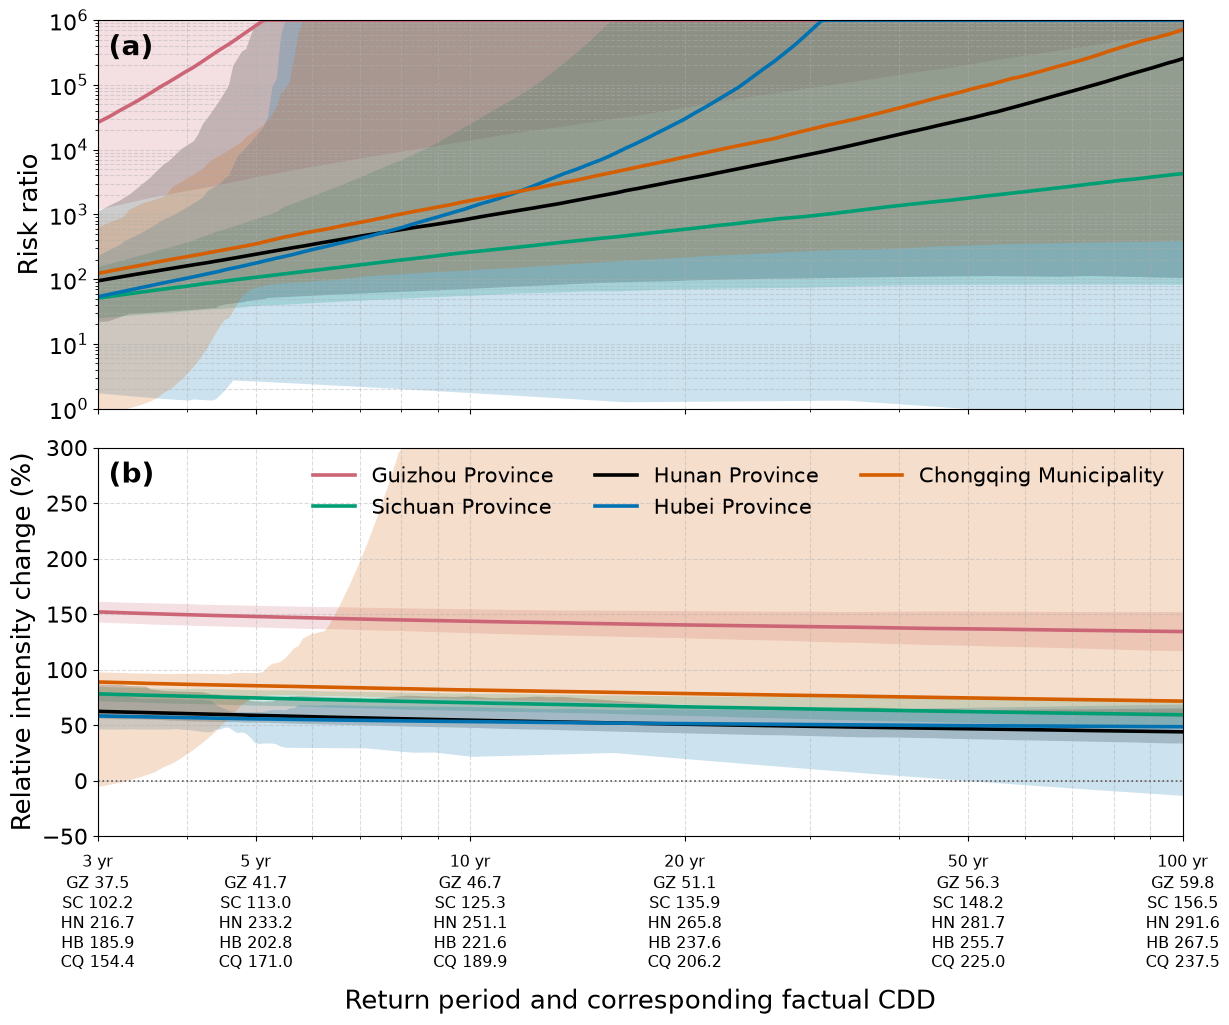


Completed successfully.
Shared family: genextreme


In [7]:
# parametric based bootstrapping another try

"""
Parametric-bootstrap analysis of Risk Ratio (RR) and
Relative Intensity Change (RIC) versus return period.

Purpose
-------
Show how RR and RIC change as CDD events become rarer and more extreme.

Method
------
1. Load the previously fitted factual and counterfactual distributions.
2. Keep the same shared distribution family for all provinces and both worlds.
3. For each bootstrap replicate:
   - simulate a sample from each fitted distribution;
   - use the original ensemble sample size;
   - refit the same shared family;
   - calculate RR and RIC over the return-period grid.
4. Plot the bootstrap median as the single line for each province.
5. Plot the matching pointwise 95% bootstrap interval as the shaded band.

Definitions
-----------
Factual return value:
    x_F(T) = F_F^{-1}(1 - 1/T)

Counterfactual return value:
    x_CF(T) = F_CF^{-1}(1 - 1/T)

Risk ratio at the factual return-value threshold:
    RR(T) = P_F(X >= x_F(T)) / P_CF(X >= x_F(T))

Because P_F(X >= x_F(T)) = 1/T:
    RR(T) = (1/T) / P_CF(X >= x_F(T))

Relative intensity change:
    RIC(T) = 100 * [x_F(T) - x_CF(T)] / x_CF(T)

Important interpretation
------------------------
This is a model-based parametric bootstrap. Its uncertainty is conditional on
the fitted shared distribution family being an adequate representation of the
data, especially in the tail.
"""

from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ============================================================
# USER SETTINGS
# ============================================================

FIT_STORE_PATH = Path(
    "/home/users/weijia_6/Yangtze_code/demand_result/"
    "fit_store_shared_family.pkl"
)

OUT_DIR = Path(
    "/home/users/weijia_6/Yangtze_code/demand_result"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PROVINCES = [
    "Guizhou Province",
    "Sichuan Province",
    "Hunan Province",
    "Hubei Province",
    "Chongqing Municipality",
]

PROVINCE_ABBREVIATIONS = {
    "Guizhou Province": "GZ",
    "Sichuan Province": "SC",
    "Hunan Province": "HN",
    "Hubei Province": "HB",
    "Chongqing Municipality": "CQ",
}

PROVINCE_COLORS = {
    "Guizhou Province": "#CC6677",
    "Sichuan Province": "#009E73",
    "Hunan Province": "#000000",
    "Hubei Province": "#0072B2",
    "Chongqing Municipality": "#D55E00",
}

# Return-period settings.
# Do not begin at T = 1 because ppf(0) may be infinite.
# RP_MIN = 5.0 # 1.01
RP_MIN = 3.0
RP_MAX = 100.0
N_RP = 250

RP_GRID = np.logspace(
    np.log10(RP_MIN),
    np.log10(RP_MAX),
    N_RP,
)

RP_TICKS = np.array(
    [3, 5, 10, 20, 50, 100],
    dtype=float,
)

# RP_TICKS = np.array([5, 10, 20, 50, 100], dtype=float)

# Bootstrap settings.
N_BOOT = 1000
RANDOM_SEED = 42

# Numerical plotting limits.
# These caps are display/summary safeguards for extremely large values.
RR_CAP = 1e6
RIC_MIN = -300.0
RIC_MAX = 300.0

# Plot settings.
FIGSIZE = (14, 12)
LABEL_SIZE = 19
TICK_SIZE = 16
LEGEND_SIZE = 15
LINE_WIDTH = 2.6
BAND_ALPHA = 0.20

RR_YMIN = 1.0
RR_YMAX = RR_CAP
RIC_YMIN = -50.0
RIC_YMAX = 300.0


# ============================================================
# LOAD AND VALIDATE FIT STORE
# ============================================================

if not FIT_STORE_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find fit store:\n{FIT_STORE_PATH}\n"
        "Run the shared-family fitting script first."
    )

with FIT_STORE_PATH.open("rb") as file:
    fit_store = pickle.load(file)

missing_provinces = [
    province
    for province in PROVINCES
    if province not in fit_store
]

if missing_provinces:
    raise KeyError(
        "These provinces are missing from fit_store: "
        + ", ".join(missing_provinces)
    )

shared_families = {
    fit_store[province]["shared_family"]
    for province in PROVINCES
}

if len(shared_families) != 1:
    raise ValueError(
        "All provinces must use the same shared distribution family. "
        f"Found: {sorted(shared_families)}"
    )

SHARED_FAMILY = next(iter(shared_families))

if not hasattr(stats, SHARED_FAMILY):
    raise AttributeError(
        f"scipy.stats does not contain distribution '{SHARED_FAMILY}'."
    )

dist_family = getattr(stats, SHARED_FAMILY)
rng = np.random.default_rng(RANDOM_SEED)

print(f"Using shared distribution family: {SHARED_FAMILY}")
print("Parametric bootstrap sample sizes match the original ensembles.")


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def clean_sample(values):
    """Return finite one-dimensional ensemble values."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size < 10:
        raise ValueError("Too few finite values after cleaning.")

    return values


def return_value_from_rp(dist, rp):
    """
    Return value associated with return period T:

        x(T) = F^{-1}(1 - 1/T)
    """
    rp = np.asarray(rp, dtype=float)

    if np.any(rp <= 1.0):
        raise ValueError("All return periods must be greater than 1.")

    probability = 1.0 - 1.0 / rp

    with np.errstate(
        over="ignore",
        under="ignore",
        divide="ignore",
        invalid="ignore",
    ):
        values = dist.ppf(probability)

    return np.asarray(values, dtype=float)


def risk_ratio_curve(dist_f, dist_cf, rp):
    """
    Calculate RR at the factual-world return-value threshold.

    logsf is used for numerical stability in the counterfactual tail.
    Extremely large finite or infinite RR values are capped at RR_CAP.
    """
    rp = np.asarray(rp, dtype=float)
    threshold_f = return_value_from_rp(dist_f, rp)

    result = np.full(rp.shape, np.nan, dtype=float)

    valid_threshold = np.isfinite(threshold_f)

    if not np.any(valid_threshold):
        return result

    with np.errstate(
        over="ignore",
        under="ignore",
        divide="ignore",
        invalid="ignore",
    ):
        log_p_factual = -np.log(rp[valid_threshold])
        log_p_counterfactual = dist_cf.logsf(
            threshold_f[valid_threshold]
        )
        log_rr = log_p_factual - log_p_counterfactual

    valid_indices = np.where(valid_threshold)[0]

    # Finite log-RR values.
    finite_mask = np.isfinite(log_rr)
    finite_indices = valid_indices[finite_mask]

    if finite_indices.size > 0:
        finite_rr = np.exp(
            np.minimum(
                log_rr[finite_mask],
                np.log(RR_CAP),
            )
        )
        result[finite_indices] = finite_rr

    # Positive infinity means the counterfactual probability is effectively
    # zero or the threshold is beyond the fitted counterfactual support.
    infinite_mask = np.isposinf(log_rr)
    infinite_indices = valid_indices[infinite_mask]

    if infinite_indices.size > 0:
        result[infinite_indices] = RR_CAP

    return np.clip(result, 1e-12, RR_CAP)


def relative_intensity_change_curve(
    dist_f,
    dist_cf,
    rp,
):
    """
    Calculate RIC at a common return period.

        RIC(T) = 100 * [x_F(T) - x_CF(T)] / x_CF(T)

    Extreme values are capped only to keep the plotted interval readable.
    """
    return_f = return_value_from_rp(dist_f, rp)
    return_cf = return_value_from_rp(dist_cf, rp)

    with np.errstate(
        over="ignore",
        under="ignore",
        divide="ignore",
        invalid="ignore",
    ):
        result = (
            100.0
            * (return_f - return_cf)
            / return_cf
        )

    result = np.where(
        np.isfinite(result),
        result,
        np.nan,
    )

    return np.clip(
        result,
        RIC_MIN,
        RIC_MAX,
    )


def fit_fixed_family(sample):
    """
    Refit the fixed shared distribution family.

    Runtime warnings from scipy are suppressed during fitting, while failed
    fits are returned as None and skipped.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        try:
            params = dist_family.fit(sample)
            frozen_dist = dist_family(*params)
        except Exception:
            return None, None

    params = np.asarray(params, dtype=float)

    if not np.all(np.isfinite(params)):
        return None, None

    scale = params[-1]

    if not np.isfinite(scale) or scale <= 0.0:
        return None, None

    return frozen_dist, params


def summarise_band(bootstrap_array):
    """
    Calculate the pointwise bootstrap median and 95% interval.
    """
    bootstrap_array = np.asarray(
        bootstrap_array,
        dtype=float,
    )

    if bootstrap_array.ndim != 2:
        raise ValueError(
            "Bootstrap array must have shape "
            "(n_bootstrap, n_return_periods)."
        )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        median = np.nanpercentile(
            bootstrap_array,
            50.0,
            axis=0,
        )
        lower = np.nanpercentile(
            bootstrap_array,
            2.5,
            axis=0,
        )
        upper = np.nanpercentile(
            bootstrap_array,
            97.5,
            axis=0,
        )

    return median, lower, upper


def format_number(value):
    """Format CDD values for the x-axis labels."""
    if not np.isfinite(value):
        return "NA"

    return f"{value:.1f}"


# ============================================================
# PARAMETRIC BOOTSTRAP
# ============================================================

RR_MEDIAN = {}
RR_LOWER = {}
RR_UPPER = {}

RIC_MEDIAN = {}
RIC_LOWER = {}
RIC_UPPER = {}

BOOTSTRAP_SUMMARY_ROWS = []
PARAMETER_ROWS = []

for province_number, province in enumerate(
    PROVINCES,
    start=1,
):
    print(
        f"\n[{province_number}/{len(PROVINCES)}] "
        f"Processing {province}"
    )

    factual_values = clean_sample(
        fit_store[province]["factual"]["data"]
    )

    counterfactual_values = clean_sample(
        fit_store[province]["counterfactual"]["data"]
    )

    n_factual = factual_values.size
    n_counterfactual = counterfactual_values.size

    print(f"  Factual ensemble size: {n_factual}")
    print(
        f"  Counterfactual ensemble size: "
        f"{n_counterfactual}"
    )

    original_dist_f = (
        fit_store[province]["factual"]["dist"]
    )

    original_dist_cf = (
        fit_store[province]["counterfactual"]["dist"]
    )

    rr_bootstrap = np.full(
        (N_BOOT, N_RP),
        np.nan,
        dtype=float,
    )

    ric_bootstrap = np.full(
        (N_BOOT, N_RP),
        np.nan,
        dtype=float,
    )

    successful_bootstraps = 0

    for bootstrap_index in range(N_BOOT):
        # Parametric bootstrap:
        # generate samples from the fitted distributions.
        sample_f = original_dist_f.rvs(
            size=n_factual,
            random_state=rng,
        )

        sample_cf = original_dist_cf.rvs(
            size=n_counterfactual,
            random_state=rng,
        )

        dist_f_boot, params_f = fit_fixed_family(
            sample_f
        )

        dist_cf_boot, params_cf = fit_fixed_family(
            sample_cf
        )

        if (
            dist_f_boot is None
            or dist_cf_boot is None
        ):
            continue

        rr_values = risk_ratio_curve(
            dist_f_boot,
            dist_cf_boot,
            RP_GRID,
        )

        ric_values = (
            relative_intensity_change_curve(
                dist_f_boot,
                dist_cf_boot,
                RP_GRID,
            )
        )

        rr_bootstrap[
            bootstrap_index,
            :,
        ] = rr_values

        ric_bootstrap[
            bootstrap_index,
            :,
        ] = ric_values

        successful_bootstraps += 1

        parameter_row = {
            "Province": province,
            "Bootstrap": bootstrap_index,
            "Distribution": SHARED_FAMILY,
        }

        for parameter_index, value in enumerate(
            params_f
        ):
            parameter_row[
                f"Factual_param_{parameter_index}"
            ] = value

        for parameter_index, value in enumerate(
            params_cf
        ):
            parameter_row[
                f"Counterfactual_param_{parameter_index}"
            ] = value

        PARAMETER_ROWS.append(parameter_row)

    if successful_bootstraps == 0:
        raise RuntimeError(
            f"No successful bootstrap fits for {province}."
        )

    (
        RR_MEDIAN[province],
        RR_LOWER[province],
        RR_UPPER[province],
    ) = summarise_band(rr_bootstrap)

    (
        RIC_MEDIAN[province],
        RIC_LOWER[province],
        RIC_UPPER[province],
    ) = summarise_band(ric_bootstrap)

    print(
        f"  Successful bootstrap fits: "
        f"{successful_bootstraps}/{N_BOOT}"
    )

    BOOTSTRAP_SUMMARY_ROWS.append(
        {
            "Province": province,
            "Distribution": SHARED_FAMILY,
            "Factual_sample_size": n_factual,
            "Counterfactual_sample_size": (
                n_counterfactual
            ),
            "Requested_bootstraps": N_BOOT,
            "Successful_bootstraps": (
                successful_bootstraps
            ),
        }
    )


# ============================================================
# RETURN-PERIOD / CDD LOOKUP
# ============================================================

lookup_rows = []

for province in PROVINCES:
    dist_f = fit_store[province]["factual"]["dist"]
    dist_cf = fit_store[province]["counterfactual"]["dist"]

    factual_cdd = return_value_from_rp(
        dist_f,
        RP_TICKS,
    )

    counterfactual_cdd = return_value_from_rp(
        dist_cf,
        RP_TICKS,
    )

    for (
        return_period,
        cdd_f,
        cdd_cf,
    ) in zip(
        RP_TICKS,
        factual_cdd,
        counterfactual_cdd,
    ):
        lookup_rows.append(
            {
                "Province": province,
                "Return_period": return_period,
                "Factual_CDD": cdd_f,
                "Counterfactual_CDD": cdd_cf,
            }
        )

lookup_df = pd.DataFrame(lookup_rows)


# ============================================================
# SAVE OUTPUT TABLES
# ============================================================

curve_rows = []

for province in PROVINCES:
    for index, return_period in enumerate(
        RP_GRID
    ):
        curve_rows.append(
            {
                "Province": province,
                "Return_period": return_period,
                "RR_bootstrap_median": (
                    RR_MEDIAN[province][index]
                ),
                "RR_lower_95": (
                    RR_LOWER[province][index]
                ),
                "RR_upper_95": (
                    RR_UPPER[province][index]
                ),
                "RIC_bootstrap_median": (
                    RIC_MEDIAN[province][index]
                ),
                "RIC_lower_95": (
                    RIC_LOWER[province][index]
                ),
                "RIC_upper_95": (
                    RIC_UPPER[province][index]
                ),
            }
        )

curve_df = pd.DataFrame(curve_rows)

curve_path = (
    OUT_DIR
    / "rr_ric_parametric_bootstrap_curves.csv"
)

curve_df.to_csv(
    curve_path,
    index=False,
)

lookup_path = (
    OUT_DIR
    / "rr_ric_return_period_cdd_lookup_parametric.csv"
)

lookup_df.to_csv(
    lookup_path,
    index=False,
)

summary_df = pd.DataFrame(
    BOOTSTRAP_SUMMARY_ROWS
)

summary_path = (
    OUT_DIR
    / "rr_ric_parametric_bootstrap_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

parameter_df = pd.DataFrame(
    PARAMETER_ROWS
)

parameter_path = (
    OUT_DIR
    / "rr_ric_parametric_bootstrap_parameters.csv"
)

parameter_df.to_csv(
    parameter_path,
    index=False,
)

print(f"\nSaved curves:\n{curve_path}")
print(f"Saved CDD lookup:\n{lookup_path}")
print(f"Saved summary:\n{summary_path}")
print(f"Saved parameters:\n{parameter_path}")


# ============================================================
# MULTILINE X-TICK LABELS
# ============================================================

multiline_tick_labels = []

for return_period in RP_TICKS:
    lines = [f"{return_period:g} yr"]

    for province in PROVINCES:
        matching_value = lookup_df.loc[
            (
                lookup_df["Province"]
                == province
            )
            & np.isclose(
                lookup_df["Return_period"],
                return_period,
            ),
            "Factual_CDD",
        ]

        cdd_value = (
            matching_value.iloc[0]
            if not matching_value.empty
            else np.nan
        )

        lines.append(
            f"{PROVINCE_ABBREVIATIONS[province]} "
            f"{format_number(cdd_value)}"
        )

    multiline_tick_labels.append(
        "\n".join(lines)
    )


# ============================================================
# TWO-PANEL FIGURE
# ============================================================

plt.rcParams.update(
    {
        "axes.labelsize": LABEL_SIZE,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": TICK_SIZE,
        "legend.fontsize": LEGEND_SIZE,
    }
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=FIGSIZE,
    sharex=True,
    gridspec_kw={"hspace": 0.10},
)

ax_rr = axes[0]
ax_ric = axes[1]


# ---------------- Panel (a): RR ----------------

ax_rr.text(
    0.01,
    0.91,
    "(a)",
    transform=ax_rr.transAxes,
    fontsize=20,
    fontweight="bold",
)

for province in PROVINCES:
    color = PROVINCE_COLORS[province]

    ax_rr.plot(
        RP_GRID,
        RR_MEDIAN[province],
        color=color,
        linewidth=LINE_WIDTH,
        label=province,
    )

    ax_rr.fill_between(
        RP_GRID,
        RR_LOWER[province],
        RR_UPPER[province],
        color=color,
        alpha=BAND_ALPHA,
        linewidth=0,
    )

ax_rr.set_xscale("log")
ax_rr.set_yscale("log")
ax_rr.set_ylabel("Risk ratio")

ax_rr.set_xlim(
    RP_TICKS.min(),
    RP_TICKS.max(),
)

ax_rr.set_ylim(
    RR_YMIN,
    RR_YMAX,
)

ax_rr.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.45,
)

ax_rr.tick_params(
    axis="x",
    labelbottom=False,
)


# ---------------- Panel (b): RIC ----------------

ax_ric.text(
    0.01,
    0.91,
    "(b)",
    transform=ax_ric.transAxes,
    fontsize=20,
    fontweight="bold",
)

for province in PROVINCES:
    color = PROVINCE_COLORS[province]

    ax_ric.plot(
        RP_GRID,
        RIC_MEDIAN[province],
        color=color,
        linewidth=LINE_WIDTH,
    )

    ax_ric.fill_between(
        RP_GRID,
        RIC_LOWER[province],
        RIC_UPPER[province],
        color=color,
        alpha=BAND_ALPHA,
        linewidth=0,
    )

ax_ric.axhline(
    0.0,
    color="0.35",
    linestyle=":",
    linewidth=1.2,
)

ax_ric.set_xscale("log")

ax_ric.set_ylabel(
    "Relative intensity change (%)"
)

ax_ric.set_xlabel(
    "Return period and corresponding factual CDD",
    labelpad=12,
)

ax_ric.set_xlim(
    RP_TICKS.min(),
    RP_TICKS.max(),
)

ax_ric.set_ylim(
    RIC_YMIN,
    RIC_YMAX,
)

ax_ric.set_xticks(
    RP_TICKS
)

ax_ric.set_xticklabels(
    multiline_tick_labels,
    fontsize=11.5,
    linespacing=1.25,
)

ax_ric.tick_params(
    axis="x",
    pad=8,
)

ax_ric.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.45,
)

# Legend only in the lower-right of the bottom panel.
handles, labels = (
    ax_rr.get_legend_handles_labels()
)

# ax_ric.legend(
#     handles,
#     labels,
#     loc="upper right",
#     frameon=False,
#     fontsize=LEGEND_SIZE,
# )

ax_ric.legend(
    handles,
    labels,
    loc="upper right",
    ncol=3,
    frameon=False,
    fontsize=LEGEND_SIZE,
)

# fig.suptitle(
#     "Risk ratio and relative intensity change versus return period\n"
#     "Parametric bootstrap using the shared fitted distribution family",
#     fontsize=20,
#     y=0.995,
# )

# Province abbreviations can be explained in the figure caption.
fig.subplots_adjust(
    bottom=0.20,
)

figure_path = (
    OUT_DIR
    / "rr_ric_parametric_bootstrap_final.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Saved figure:\n{figure_path}")

plt.show()
plt.close(fig)

print("\nCompleted successfully.")
print(f"Shared family: {SHARED_FAMILY}")

Key findings (for manuscript):
The parametric bootstrap analysis indicates that high CDD events are substantially more probable and more intense in the factual climate than in the counterfactual climate across all five provinces. Risk ratios increase strongly with return period, demonstrating a strengthening probability attribution signal for rarer and more extreme events. Guizhou shows the largest increase in both event probability and intensity, followed by Chongqing and Hunan in terms of risk ratio. Relative intensity changes remain positive across all return periods but generally decline gradually as events become more extreme. Uncertainty increases toward longer return periods, particularly for the RR estimates, reflecting the greater dependence of rare-event probabilities on the fitted distribution tails.

Figure-caption interpretation could be:
Solid lines show median RR and RIC from the parametric bootstrap, and shaded regions show pointwise 95% intervals. RR increases markedly with return period in all provinces, while RIC remains positive but generally declines gradually. Guizhou exhibits the strongest attribution signal.

## Step 3 Spatial visualisation - point estimate result

Attribution analysis - spatial visualisation

Using shared family for M2: genextreme
Saved M2 summary to: /home/users/weijia_6/Yangtze_code/demand_result/method2_point_estimates_summary_fixed.csv
Shared plotting ranges based on five provinces only:
RIC: 32.428 to 189.376
RR:  11.370 to 92.262


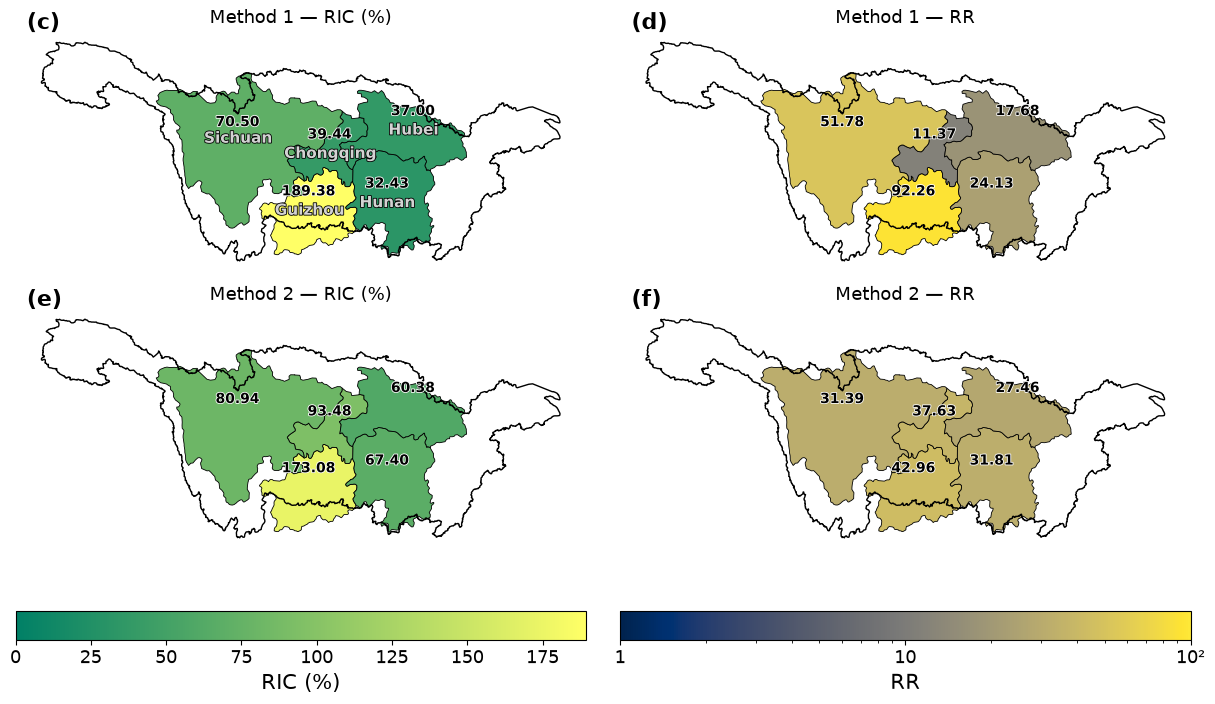

Saved figure to: /home/users/weijia_6/Yangtze_code/demand_result/yangtze_m1_m2_point_estimate_maps_fixed.png
                        selected_percentile  event_threshold_cdd  \
Province                                                           
Sichuan Province                       55.0            94.752512   
Chongqing Municipality                 45.0           133.575256   
Hubei Province                         55.0           173.735652   
Hunan Province                         45.0           194.390628   
Guizhou Province                       10.0            23.705954   

                        factual_return_period  counterfactual_return_period  \
Province                                                                      
Sichuan Province                     2.227124                     69.909051   
Chongqing Municipality               1.812601                     68.207674   
Hubei Province                       2.205034                     60.560578   
Hunan Province     

In [2]:
# Spatial visualisation -  M1 & M2 point estimate result
"""
Spatial visualisation of attribution point estimates for the five Yangtze provinces.

Panels:
  (a) M1 RIC
  (b) M1 RR
  (c) M2 RIC
  (d) M2 RR

M1:
  Loaded from the statistical attribution CSV.

M2:
  Computed from the fitted HadGEM factual/counterfactual distributions,
  using a factual percentile threshold chosen from each province's factual
  ensemble (100th, 95th, 90th, ... until there is counterfactual overlap).
"""

from pathlib import Path
import pickle
import warnings

import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.patheffects as PathEffects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# PATHS
# ============================================================

M1_CSV = Path(
    "/home/users/weijia_6/Yangtze_code/"
    "method_1_result/combined_attribution_results_clean.csv"
)

FIT_STORE_PATH = Path(
    "/home/users/weijia_6/Yangtze_code/demand_result/"
    "fit_store_shared_family.pkl"
)

CHINA_SHP = Path(
    "/home/users/weijia_6/Yangtze_code/geoBoundaries-CHN-ADM1-all/"
    "geoBoundaries-CHN-ADM1.shp"
)

YANGTZE_SHP = Path(
    "/home/users/weijia_6/Yangtze_code/liuyu/liuyu.shp"
)

OUT_DIR = Path("/home/users/weijia_6/Yangtze_code/demand_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG = OUT_DIR / "yangtze_m1_m2_point_estimate_maps_fixed.png"
OUT_M2 = OUT_DIR / "method2_point_estimates_summary_fixed.csv"

# ============================================================
# SETTINGS
# ============================================================

FIVE = [
    "Sichuan Province",
    "Chongqing Municipality",
    "Hubei Province",
    "Hunan Province",
    "Guizhou Province",
]

SHORT = {
    "Sichuan Province": "Sichuan",
    "Chongqing Municipality": "Chongqing",
    "Hubei Province": "Hubei",
    "Hunan Province": "Hunan",
    "Guizhou Province": "Guizhou",
}

CANDIDATE_PERCENTILES = list(range(100, 0, -5))
if 1 not in CANDIDATE_PERCENTILES:
    CANDIDATE_PERCENTILES.append(1)

FIGSIZE = (12.5, 7.8)
RIC_CMAP = "summer"
RR_CMAP = "cividis"
RR_LOG_MIN = 1e-3

plt.rcParams.update({
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# LOAD DATA
# ============================================================

if not CHINA_SHP.exists():
    raise FileNotFoundError(f"Missing shapefile: {CHINA_SHP}")
if not YANGTZE_SHP.exists():
    raise FileNotFoundError(f"Missing basin shapefile: {YANGTZE_SHP}")
if not M1_CSV.exists():
    raise FileNotFoundError(f"Missing M1 CSV: {M1_CSV}")
if not FIT_STORE_PATH.exists():
    raise FileNotFoundError(f"Missing fit_store pickle: {FIT_STORE_PATH}")

gdf = gpd.read_file(CHINA_SHP).to_crs("EPSG:4326")
gdf = gdf[
    ~gdf["shapeName"].isin(
        [
            "Hong Kong Special Administrative Region",
            "Macau Special Administrative Region",
            "Taiwan Province",
        ]
    )
].copy()

gdf_yangtze = gpd.read_file(YANGTZE_SHP).to_crs("EPSG:4326")

df_m1 = pd.read_csv(M1_CSV, index_col=0)

with FIT_STORE_PATH.open("rb") as f:
    fit_store = pickle.load(f)

missing = [p for p in FIVE if p not in fit_store]
if missing:
    raise KeyError(f"Missing provinces in fit_store: {missing}")

shared_families = {fit_store[p]["shared_family"] for p in FIVE}
if len(shared_families) != 1:
    raise ValueError(f"Multiple shared families found: {sorted(shared_families)}")

SHARED_FAMILY = next(iter(shared_families))
if not hasattr(stats, SHARED_FAMILY):
    raise AttributeError(f"scipy.stats has no distribution '{SHARED_FAMILY}'")

dist_family = getattr(stats, SHARED_FAMILY)
print(f"Using shared family for M2: {SHARED_FAMILY}")

# ============================================================
# HELPERS
# ============================================================

def clean_array(arr):
    arr = np.asarray(arr, dtype=float)
    return arr[np.isfinite(arr)]

# def select_threshold_from_factual(factual_values, counterfactual_values):
#     factual_values = clean_array(factual_values)
#     counterfactual_values = clean_array(counterfactual_values)

#     if factual_values.size == 0 or counterfactual_values.size == 0:
#         raise ValueError("Empty factual or counterfactual ensemble.")

#     max_cf = np.nanmax(counterfactual_values)

#     for pct in CANDIDATE_PERCENTILES:
#         thr = float(np.nanpercentile(factual_values, pct))
#         if np.isfinite(thr) and thr <= max_cf:
#             return float(pct), thr

#     warnings.warn(
#         "No factual percentile threshold had overlap with the counterfactual ensemble; "
#         "using the lowest candidate percentile.",
#         RuntimeWarning,
#     )
#     pct = float(CANDIDATE_PERCENTILES[-1])
#     thr = float(np.nanpercentile(factual_values, pct))
#     return pct, thr

# Ensure at least 5 or 10 counterfactual members above the threshold, or a minimum counterfactual exceedance probability like 1% for stable results
def select_threshold_from_factual(factual_values, counterfactual_values,
                                  min_cf_count=5, min_cf_prob=0.01):
    """
    Pick the highest factual percentile threshold that still has enough
    counterfactual support.

    min_cf_count: minimum number of counterfactual ensemble members above threshold
    min_cf_prob:  minimum exceedance probability in counterfactual world
    """
    factual_values = clean_array(factual_values)
    counterfactual_values = clean_array(counterfactual_values)

    if factual_values.size == 0 or counterfactual_values.size == 0:
        raise ValueError("Empty factual or counterfactual data.")

    n_cf = counterfactual_values.size

    for pct in CANDIDATE_PERCENTILES:
        thr = float(np.nanpercentile(factual_values, pct))
        if not np.isfinite(thr):
            continue

        cf_count = int(np.sum(counterfactual_values >= thr))
        cf_prob = cf_count / n_cf

        if cf_count >= min_cf_count and cf_prob >= min_cf_prob:
            return pct, thr

    # fallback: lowest candidate percentile
    pct = CANDIDATE_PERCENTILES[-1]
    thr = float(np.nanpercentile(factual_values, pct))
    warnings.warn(
        "No factual percentile had sufficient counterfactual support; "
        "using the lowest candidate percentile.",
        RuntimeWarning,
    )
    return pct, thr

def m1_metrics(row):
    def first_existing(candidates):
        for c in candidates:
            if c in row.index and pd.notna(row[c]):
                return float(row[c])
        raise KeyError(f"Could not find any of {candidates} in M1 row")

    rr = first_existing(["PR_est", "RR", "PR"])
    ric = first_existing(["dI_rel_est", "dl_rel_est", "rel_intensity_change_percent"])
    return rr, ric

def build_m1_dataframe(df_m1_in):
    rows = []
    for prov in FIVE:
        if prov not in df_m1_in.index:
            rows.append({"Province": prov, "RR_m1": np.nan, "RIC_m1": np.nan})
            continue
        rr, ric = m1_metrics(df_m1_in.loc[prov])
        rows.append({"Province": prov, "RR_m1": rr, "RIC_m1": ric})
    return pd.DataFrame(rows).set_index("Province")

def compute_m2_for_province(prov):
    factual = clean_array(fit_store[prov]["factual"]["data"])
    counterfactual = clean_array(fit_store[prov]["counterfactual"]["data"])
    dist_f = fit_store[prov]["factual"]["dist"]
    dist_cf = fit_store[prov]["counterfactual"]["dist"]

    selected_pct, threshold = select_threshold_from_factual(factual, counterfactual)

    p_f = float(dist_f.sf(threshold))
    p_cf = float(dist_cf.sf(threshold))

    if not np.isfinite(p_f) or p_f <= 0:
        rr = np.nan
        factual_rp = np.nan
        ric = np.nan
    else:
        factual_rp = 1.0 / p_f
        rr = np.inf if (not np.isfinite(p_cf) or p_cf <= 0) else p_f / p_cf
        q_f = float(dist_f.ppf(1.0 - 1.0 / factual_rp))
        q_cf = float(dist_cf.ppf(1.0 - 1.0 / factual_rp))
        ric = np.nan if (not np.isfinite(q_f) or not np.isfinite(q_cf) or q_cf <= 0) else 100.0 * (q_f - q_cf) / q_cf

    return pd.Series(
        {
            "selected_percentile": selected_pct,
            "event_threshold_cdd": threshold,
            "factual_return_period": factual_rp,
            "RR_m2": rr,
            "RIC_m2": ric,
            "factual_exceedance_prob": p_f,
            "counterfactual_exceedance_prob": p_cf,
        }
    )

def add_province_labels(ax, gdf_in):
    for _, row in gdf_in.iterrows():
        prov = row["shapeName"]
        if prov not in SHORT:
            continue
        pt = row.geometry.representative_point()
        x, y = pt.x, pt.y
        if prov == "Sichuan Province":
            y += 0.6
        elif prov == "Chongqing Municipality":
            y -= 0.25
        ax.text(
            x, y, SHORT[prov],
            fontsize=11,
            color="lightgrey",
            ha="center",
            va="center",
            fontweight="bold",
            path_effects=[PathEffects.withStroke(linewidth=1.2, foreground="black")],
        )

def add_value_tags(ax, gdf_in, column, fmt="2dec", y_offset=1.0):
    for _, row in gdf_in.iterrows():
        val = row[column]
        if pd.isna(val):
            continue

        if np.isposinf(val):
            text = "∞"
        elif fmt == "1dec":
            text = f"{val:.1f}"
        elif fmt == "2dec":
            text = f"{val:.2f}"
        elif fmt == "int":
            text = f"{int(round(val))}"
        else:
            text = f"{val}"

        pt = row.geometry.representative_point()
        x, y = pt.x, pt.y + y_offset
        if row["shapeName"] == "Sichuan Province":
            y += 0.45
        elif row["shapeName"] == "Chongqing Municipality":
            y -= 0.25

        ax.text(
            x, y, text,
            fontsize=10,
            color="black",
            ha="center",
            va="center",
            fontweight="bold",
            path_effects=[PathEffects.withStroke(linewidth=1.2, foreground="white")],
        )

def plot_panel(ax, gdf_in, column, title, cmap, norm, value_fmt="2dec", show_labels=False):
    gdf_in.plot(
        column=column,
        cmap=cmap,
        linewidth=0.6,
        edgecolor="black",
        legend=False,
        norm=norm,
        ax=ax,
        missing_kwds={"color": "lightgrey"},
    )
    gdf_yangtze.boundary.plot(ax=ax, color="black", linewidth=1.0)
    if show_labels:
        add_province_labels(ax, gdf_in)
    add_value_tags(ax, gdf_in, column, fmt=value_fmt)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

# ============================================================
# BUILD DATAFRAMES
# ============================================================

df_m1_map = build_m1_dataframe(df_m1)

m2_rows = []
for prov in FIVE:
    row = compute_m2_for_province(prov)
    row["Province"] = prov
    m2_rows.append(row)

df_m2 = pd.DataFrame(m2_rows).set_index("Province")
df_m2.to_csv(OUT_M2)
print("Saved M2 summary to:", OUT_M2)

# Merge onto geometry
gdf_plot = gdf[gdf["shapeName"].isin(FIVE)].copy()
gdf_plot = gdf_plot.merge(df_m1_map, left_on="shapeName", right_index=True, how="left")
gdf_plot = gdf_plot.merge(df_m2, left_on="shapeName", right_index=True, how="left")


# ============================================================
# Calculate the return periods
# ============================================================
def compute_m2_for_province(prov):
    factual = clean_array(fit_store[prov]["factual"]["data"])
    counterfactual = clean_array(fit_store[prov]["counterfactual"]["data"])
    dist_f = fit_store[prov]["factual"]["dist"]
    dist_cf = fit_store[prov]["counterfactual"]["dist"]

    selected_pct, threshold = select_threshold_from_factual(factual, counterfactual)

    p_f = float(dist_f.sf(threshold))
    p_cf = float(dist_cf.sf(threshold))

    if not np.isfinite(p_f) or p_f <= 0:
        factual_rp = np.nan
        counterfactual_rp = np.nan
        rr = np.nan
        ric = np.nan
    else:
        factual_rp = 1.0 / p_f
        counterfactual_rp = np.inf if (not np.isfinite(p_cf) or p_cf <= 0) else 1.0 / p_cf
        rr = np.inf if (not np.isfinite(p_cf) or p_cf <= 0) else p_f / p_cf

        q_f = float(dist_f.ppf(1.0 - 1.0 / factual_rp))
        q_cf = float(dist_cf.ppf(1.0 - 1.0 / factual_rp))
        ric = np.nan if (not np.isfinite(q_f) or not np.isfinite(q_cf) or q_cf <= 0) else 100.0 * (q_f - q_cf) / q_cf

    return pd.Series({
        "selected_percentile": selected_pct,
        "event_threshold_cdd": threshold,
        "factual_return_period": factual_rp,
        "counterfactual_return_period": counterfactual_rp,
        "RR_m2": rr,
        "RIC_m2": ric,
        "factual_exceedance_prob": p_f,
        "counterfactual_exceedance_prob": p_cf,
    })

m2_rows = []
for prov in FIVE:
    row = compute_m2_for_province(prov)
    row["Province"] = prov
    m2_rows.append(row)

df_m2 = pd.DataFrame(m2_rows).set_index("Province")



# ============================================================
# PLOTTING RANGES
# ============================================================

ric_vals = pd.concat([gdf_plot["RIC_m1"], gdf_plot["RIC_m2"]], axis=0)
ric_vals = pd.to_numeric(ric_vals, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

rr_vals = pd.concat([gdf_plot["RR_m1"], gdf_plot["RR_m2"]], axis=0)
rr_vals = pd.to_numeric(rr_vals, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
rr_vals = rr_vals[rr_vals > 0]

if len(ric_vals) == 0 or len(rr_vals) == 0:
    raise ValueError("No valid values available for plotting ranges.")

ric_vmin, ric_vmax = float(ric_vals.min()), float(ric_vals.max())
rr_vmin, rr_vmax = float(rr_vals.min()), float(rr_vals.max())

print("Shared plotting ranges based on five provinces only:")
print(f"RIC: {ric_vmin:.3f} to {ric_vmax:.3f}")
print(f"RR:  {rr_vmin:.3f} to {rr_vmax:.3f}")

ric_norm = colors.Normalize(vmin=min(0, ric_vmin), vmax=max(80, ric_vmax))
# rr_norm = colors.LogNorm(vmin=max(RR_LOG_MIN, 1e-3), vmax=max(rr_vmax, 1.0))
# rr_norm = colors.LogNorm(vmin=max(RR_LOG_MIN, 0), vmax=max(rr_vmax, 1.0))

# # Replace infinite RR with a visible value for plotting
# rr_display_cap = rr_vmax * 1.02 if np.isfinite(rr_vmax) and rr_vmax > 0 else 10.0
# gdf_plot["RR_m2_plot"] = gdf_plot["RR_m2"].replace([np.inf, -np.inf], np.nan)
# gdf_plot.loc[gdf_plot["RR_m2_plot"].isna(), "RR_m2_plot"] = rr_display_cap

# rr_norm = colors.LogNorm(vmin=max(RR_LOG_MIN, 1e-3), vmax=max(rr_vmax, 1.0))

# # Replace infinite RR with a visible value for plotting
# rr_display_cap = rr_vmax * 1.02 if np.isfinite(rr_vmax) and rr_vmax > 0 else 10.0
# gdf_plot["RR_m2_plot"] = gdf_plot["RR_m2"].replace([np.inf, -np.inf], np.nan)
# gdf_plot.loc[gdf_plot["RR_m2_plot"].isna(), "RR_m2_plot"] = rr_display_cap


# ============================================================
# FIXED RR COLOURBAR RANGE (1 → 10^3)
# ============================================================

RR_MIN = 1
# RR_MAX = 1e3
RR_MAX = 1e2

# Clip RR values to colourbar range
gdf_plot["RR_m2_plot"] = gdf_plot["RR_m2"].clip(lower=RR_MIN, upper=RR_MAX)

# Log colour scale from 1 to 1000
rr_norm = colors.LogNorm(vmin=RR_MIN, vmax=RR_MAX)



# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)

# panel_labels = ["(a)", "(b)", "(c)", "(d)"]
panel_labels = ["(c)", "(d)", "(e)", "(f)"]
for ax, label in zip(axes.flatten(), panel_labels):
    ax.text(
        0.02, 1.08, label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

plot_panel(
    axes[0, 0],
    gdf_plot,
    "RIC_m1",
    "Method 1 — RIC (%)",
    RIC_CMAP,
    ric_norm,
    value_fmt="2dec",
    show_labels=True,
)

plot_panel(
    axes[0, 1],
    gdf_plot,
    "RR_m1",
    "Method 1 — RR",
    RR_CMAP,
    rr_norm,
    value_fmt="2dec",
    show_labels=False,
)

plot_panel(
    axes[1, 0],
    gdf_plot,
    "RIC_m2",
    "Method 2 — RIC (%)",
    RIC_CMAP,
    ric_norm,
    value_fmt="2dec",
    show_labels=False,
)

plot_panel(
    axes[1, 1],
    gdf_plot,
    "RR_m2_plot",
    "Method 2 — RR",
    RR_CMAP,
    rr_norm,
    value_fmt="2dec",
    show_labels=False,
)

fig.subplots_adjust(
    left=0.04,
    right=0.98,
    top=0.92,
    bottom=0.12,
    wspace=0.06,
    hspace=0.12,
)

sm1 = cm.ScalarMappable(norm=ric_norm, cmap=RIC_CMAP)
sm1.set_array([])
cb1 = fig.colorbar(sm1, ax=axes[:, 0], orientation="horizontal", fraction=0.06, pad=0.10)
cb1.set_label("RIC (%)", fontsize=15)
cb1.ax.tick_params(labelsize=13)

# sm2 = cm.ScalarMappable(norm=rr_norm, cmap=RR_CMAP)
# sm2.set_array([])
# cb2 = fig.colorbar(sm2, ax=axes[:, 1], orientation="horizontal", fraction=0.06, pad=0.10)
# cb2.set_label("RR", fontsize=15)
# cb2.ax.tick_params(labelsize=13)


# ============================================================
# RR COLORBAR (FIXED RANGE)
# ============================================================

sm_rr = cm.ScalarMappable(norm=rr_norm, cmap=RR_CMAP)
sm_rr.set_array([])

cb_rr = fig.colorbar(
    sm_rr,
    ax=axes[:, 1],
    orientation="horizontal",
    fraction=0.06,
    pad=0.10
)

cb_rr.set_label("RR", fontsize=15)
cb_rr.ax.tick_params(labelsize=13)

# Explicit log ticks
# cb_rr.set_ticks([1, 10, 100, 1000])
# cb_rr.set_ticklabels(["1", "10", "10²", "10³"])
cb_rr.set_ticks([1, 10, 100])
cb_rr.set_ticklabels(["1", "10", "10²"])


# fig.suptitle(
#     "Yangtze 5-province attribution maps: M1 vs M2 point estimates",
#     fontsize=16,
#     y=0.98,
# )

plt.savefig(OUT_FIG, dpi=400, bbox_inches="tight")
plt.show()
plt.close()

print("Saved figure to:", OUT_FIG)
print(df_m2)


# ============================================================
# Print the return period for factual/counterfactual worlds
# ============================================================
df_m2_table = df_m2[
    [
        "selected_percentile",
        "event_threshold_cdd",
        "factual_return_period",
        "counterfactual_return_period",
        "factual_exceedance_prob",
        "counterfactual_exceedance_prob",
        "RR_m2",
        "RIC_m2",
    ]
].copy()

# Make infinities easier to read in the printed table
df_m2_table["counterfactual_return_period"] = df_m2_table["counterfactual_return_period"].replace(np.inf, np.nan)

print("\nMethod 2 return-period summary:")
print(df_m2_table.round(4).to_string())

df_m2_table.to_csv(OUT_M2.with_name("method2_return_period_summary.csv"))
print(f"\nSaved table to: {OUT_M2.with_name('method2_return_period_summary.csv')}")

In [ ]:
#



Using shared family for M2: genextreme
Saved:
 - /home/users/weijia_6/Yangtze_code/demand_result/method1_summary_for_plot.csv
 - /home/users/weijia_6/Yangtze_code/demand_result/method2_summary_for_plot.csv
 - /home/users/weijia_6/Yangtze_code/demand_result/method2_selected_thresholds.csv


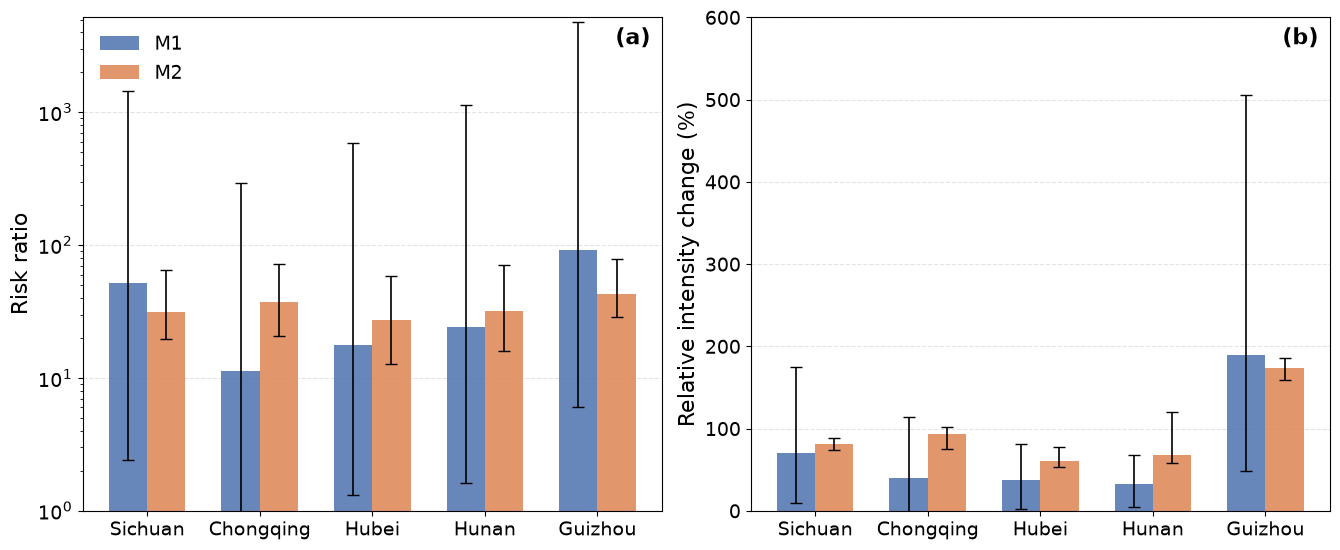

Saved figure to: /home/users/weijia_6/Yangtze_code/demand_result/province_level_m1_m2_rr_ric.png
Selected M2 thresholds:
                        selected_percentile  event_threshold_cdd  \
Province                                                           
Sichuan Province                         55            94.752512   
Chongqing Municipality                   45           133.575256   
Hubei Province                           55           173.735652   
Hunan Province                           45           194.390628   
Guizhou Province                         10            23.705954   

                        factual_return_period  
Province                                       
Sichuan Province                     2.227124  
Chongqing Municipality               1.812601  
Hubei Province                       2.205034  
Hunan Province                       1.789193  
Guizhou Province                     1.125500  


In [17]:
#  Point estimate and 95 CI result for M1 and M2

"""
Province-level comparison of attribution results for 5 Yangtze provinces.

Figure layout
-------------
One figure with two panels:
  (a) RR
  (b) Relative intensity change (RIC)

For each province, show:
  - Method 1 (M1): point estimate + 95% CI from the CSV
  - Method 2 (M2): point estimate + 95% CI from HadGEM fitted distributions

M2 threshold selection
----------------------
For each province, the event threshold is taken from the factual ensemble
percentile. Starting from 100th percentile, then 95th, 90th, ... the code
chooses the first threshold for which at least one counterfactual ensemble
member is still at or above the threshold.

M2 uncertainty
--------------
M2 confidence intervals are estimated with a parametric bootstrap:
  - simulate from the fitted factual/counterfactual distributions,
  - refit the same shared family,
  - compute RR and RIC at the fixed selected threshold.

This keeps the shared family fixed and varies only the fitted parameters.
"""

from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy import stats

# ============================================================
# USER SETTINGS
# ============================================================

# Method 1 CSV (your existing statistical method)
# M1_CSV = Path(
#     "/home/users/weijia_6/Yangtze_code/"
#     "combined_attribution_results_with_FAR_correct.csv"
# )
M1_CSV = Path(
    "/home/users/weijia_6/Yangtze_code/method_1_result/"
    "combined_attribution_results_clean.csv"
)

# HadGEM fitted function store used for Method 2
FIT_STORE_PATH = Path(
    "/home/users/weijia_6/Yangtze_code/demand_result/"
    "fit_store_shared_family.pkl"
)

OUT_DIR = Path("/home/users/weijia_6/Yangtze_code/demand_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Provinces in the display order
PROVINCES = [
    "Sichuan Province",
    "Chongqing Municipality",
    "Hubei Province",
    "Hunan Province",
    "Guizhou Province",
]

PROVINCE_LABELS = {
    "Sichuan Province": "Sichuan",
    "Chongqing Municipality": "Chongqing",
    "Hubei Province": "Hubei",
    "Hunan Province": "Hunan",
    "Guizhou Province": "Guizhou",
}

# M2 threshold candidate percentiles:
# try 100, 95, 90, ... until there is at least one counterfactual overlap.
CANDIDATE_PERCENTILES = list(range(100, 0, -5))
if 1 not in CANDIDATE_PERCENTILES:
    CANDIDATE_PERCENTILES.append(1)

# Bootstrap for M2 confidence intervals
N_BOOT = 500
RANDOM_SEED = 42

# Plotting limits
RIC_PLOT_MIN = 0.0
RIC_PLOT_MAX = 600.0

# Figure style
FIGSIZE = (13.5, 5.6)
METHOD1_COLOR = "#4C72B0"
METHOD2_COLOR = "#DD8452"
BAR_WIDTH = 0.34
CAPSIZE = 4
ERROR_LINEWIDTH = 1.2

plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

# ============================================================
# LOAD DATA
# ============================================================

if not M1_CSV.exists():
    raise FileNotFoundError(f"Cannot find M1 CSV: {M1_CSV}")

if not FIT_STORE_PATH.exists():
    raise FileNotFoundError(f"Cannot find fit_store file: {FIT_STORE_PATH}")

df_m1 = pd.read_csv(M1_CSV, index_col=0)
with FIT_STORE_PATH.open("rb") as f:
    fit_store = pickle.load(f)

missing = [p for p in PROVINCES if p not in fit_store]
if missing:
    raise KeyError(f"These provinces are missing from fit_store: {missing}")

shared_families = {fit_store[p]["shared_family"] for p in PROVINCES}
if len(shared_families) != 1:
    raise ValueError(f"Multiple shared families found: {sorted(shared_families)}")

SHARED_FAMILY = next(iter(shared_families))
if not hasattr(stats, SHARED_FAMILY):
    raise AttributeError(f"scipy.stats has no distribution '{SHARED_FAMILY}'")

dist_family = getattr(stats, SHARED_FAMILY)
rng = np.random.default_rng(RANDOM_SEED)

print(f"Using shared family for M2: {SHARED_FAMILY}")

# ============================================================
# HELPERS
# ============================================================

def clean_array(arr):
    arr = np.asarray(arr, dtype=float)
    return arr[np.isfinite(arr)]


def resolve_first_existing(row, candidates, label):
    for c in candidates:
        if c in row.index and pd.notna(row[c]):
            return float(row[c])
    raise KeyError(f"Could not find any of {candidates} for {label}")


def resolve_m1_metrics(df_m1_in, province):
    """
    Return M1 point estimates and 95% CI for RR and RIC.
    Supports a few plausible column name variants.
    """
    row = df_m1_in.loc[province]

    rr_mid = resolve_first_existing(
        row,
        ["PR_est", "RR", "PR"],
        f"{province} RR point estimate"
    )
    rr_lo = resolve_first_existing(
        row,
        ["PR_2.5%", "RR_2.5%", "PR_lower", "RR_lower"],
        f"{province} RR lower"
    )
    rr_hi = resolve_first_existing(
        row,
        ["PR_97.5%", "RR_97.5%", "PR_upper", "RR_upper"],
        f"{province} RR upper"
    )

    ric_mid = resolve_first_existing(
        row,
        ["dI_rel_est", "dl_rel_est", "rel_intensity_change_percent"],
        f"{province} RIC point estimate"
    )
    ric_lo = resolve_first_existing(
        row,
        ["dI_rel_2.5%", "dl_rel_2.5%", "rel_intensity_change_2.5%"],
        f"{province} RIC lower"
    )
    ric_hi = resolve_first_existing(
        row,
        ["dI_rel_97.5%", "dl_rel_97.5%", "rel_intensity_change_97.5%"],
        f"{province} RIC upper"
    )

    return {
        "RR_mid": rr_mid,
        "RR_lo": rr_lo,
        "RR_hi": rr_hi,
        "RIC_mid": ric_mid,
        "RIC_lo": ric_lo,
        "RIC_hi": ric_hi,
    }


# def select_threshold_from_factual(factual_values, counterfactual_values):
#     """
#     Pick the highest factual percentile threshold with at least one
#     counterfactual value at or above the threshold.
#     """
#     factual_values = clean_array(factual_values)
#     counterfactual_values = clean_array(counterfactual_values)

#     if factual_values.size == 0 or counterfactual_values.size == 0:
#         raise ValueError("Empty factual or counterfactual data.")

#     max_cf = np.nanmax(counterfactual_values)

#     for pct in CANDIDATE_PERCENTILES:
#         thr = float(np.nanpercentile(factual_values, pct))
#         if np.isfinite(thr) and thr <= max_cf:
#             return pct, thr

#     pct = CANDIDATE_PERCENTILES[-1]
#     thr = float(np.nanpercentile(factual_values, pct))
#     warnings.warn(
#         "No factual percentile had counterfactual overlap; using the lowest candidate percentile.",
#         RuntimeWarning,
#     )
#     return pct, thr


# Ensure at least 5 or 10 counterfactual members above the threshold, or a minimum counterfactual exceedance probability like 1% for stable results
def select_threshold_from_factual(factual_values, counterfactual_values,
                                  min_cf_count=5, min_cf_prob=0.01):
    """
    Pick the highest factual percentile threshold that still has enough
    counterfactual support.

    min_cf_count: minimum number of counterfactual ensemble members above threshold
    min_cf_prob:  minimum exceedance probability in counterfactual world
    """
    factual_values = clean_array(factual_values)
    counterfactual_values = clean_array(counterfactual_values)

    if factual_values.size == 0 or counterfactual_values.size == 0:
        raise ValueError("Empty factual or counterfactual data.")

    n_cf = counterfactual_values.size

    for pct in CANDIDATE_PERCENTILES:
        thr = float(np.nanpercentile(factual_values, pct))
        if not np.isfinite(thr):
            continue

        cf_count = int(np.sum(counterfactual_values >= thr))
        cf_prob = cf_count / n_cf

        if cf_count >= min_cf_count and cf_prob >= min_cf_prob:
            return pct, thr

    # fallback: lowest candidate percentile
    pct = CANDIDATE_PERCENTILES[-1]
    thr = float(np.nanpercentile(factual_values, pct))
    warnings.warn(
        "No factual percentile had sufficient counterfactual support; "
        "using the lowest candidate percentile.",
        RuntimeWarning,
    )
    return pct, thr


def compute_rr_ric_at_threshold(dist_f, dist_cf, threshold):
    """
    Compute RR and RIC at a fixed factual threshold.
    """
    p_f = float(dist_f.sf(threshold))
    p_cf = float(dist_cf.sf(threshold))

    if not np.isfinite(p_f) or p_f <= 0:
        rr = np.nan
        factual_rp = np.nan
        ric = np.nan
        return rr, ric, factual_rp

    # Raw RR at the threshold, without arbitrary capping.
    if not np.isfinite(p_cf) or p_cf <= 0:
        rr = np.nan
    else:
        rr = p_f / p_cf

    factual_rp = 1.0 / p_f
    q_f = float(dist_f.ppf(1.0 - 1.0 / factual_rp))
    q_cf = float(dist_cf.ppf(1.0 - 1.0 / factual_rp))

    if not np.isfinite(q_f) or not np.isfinite(q_cf) or q_cf <= 0:
        ric = np.nan
    else:
        ric = 100.0 * (q_f - q_cf) / q_cf

    return rr, ric, factual_rp


def fit_shared_family(sample):
    """
    Fit the shared family and return the frozen distribution.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        try:
            params = dist_family.fit(sample)
            dist = dist_family(*params)
        except Exception:
            return None

    params = np.asarray(params, dtype=float)
    if not np.all(np.isfinite(params)):
        return None
    if params[-1] <= 0 or not np.isfinite(params[-1]):
        return None

    return dist


def bootstrap_m2_ci(factual_data, counterfactual_data, threshold, n_boot=N_BOOT):
    """
    Parametric bootstrap confidence intervals for M2 at a fixed threshold.
    """
    factual_data = clean_array(factual_data)
    counterfactual_data = clean_array(counterfactual_data)
    n_f = factual_data.size
    n_cf = counterfactual_data.size

    dist_f_orig = fit_shared_family(factual_data)
    dist_cf_orig = fit_shared_family(counterfactual_data)
    if dist_f_orig is None or dist_cf_orig is None:
        raise RuntimeError("Could not fit the original distributions for bootstrap.")

    rr_vals = []
    ric_vals = []

    for _ in range(n_boot):
        sample_f = dist_f_orig.rvs(size=n_f, random_state=rng)
        sample_cf = dist_cf_orig.rvs(size=n_cf, random_state=rng)

        dist_f = fit_shared_family(sample_f)
        dist_cf = fit_shared_family(sample_cf)
        if dist_f is None or dist_cf is None:
            continue

        rr, ric, _ = compute_rr_ric_at_threshold(dist_f, dist_cf, threshold)

        if np.isfinite(rr):
            rr_vals.append(float(rr))
        if np.isfinite(ric):
            ric_vals.append(float(np.clip(ric, RIC_PLOT_MIN, RIC_PLOT_MAX)))

    if len(rr_vals) < 20 or len(ric_vals) < 20:
        raise RuntimeError("Too few successful bootstrap replicates for CI estimation.")

    rr_vals = np.asarray(rr_vals, dtype=float)
    ric_vals = np.asarray(ric_vals, dtype=float)

    return {
        "RR_mid": float(np.nanmedian(rr_vals)),
        "RR_lo": float(np.nanpercentile(rr_vals, 2.5)),
        "RR_hi": float(np.nanpercentile(rr_vals, 97.5)),
        "RIC_mid": float(np.nanmedian(ric_vals)),
        "RIC_lo": float(np.nanpercentile(ric_vals, 2.5)),
        "RIC_hi": float(np.nanpercentile(ric_vals, 97.5)),
        "n_rr": int(rr_vals.size),
        "n_ric": int(ric_vals.size),
    }

# ============================================================
# BUILD M1 SUMMARY
# ============================================================

m1_rows = []
for prov in PROVINCES:
    m1 = resolve_m1_metrics(df_m1, prov)
    m1_rows.append({
        "Province": prov,
        **m1
    })

df_m1_summary = pd.DataFrame(m1_rows).set_index("Province")

# ============================================================
# BUILD M2 SUMMARY
# ============================================================

m2_rows = []
threshold_rows = []

for prov in PROVINCES:
    factual_data = clean_array(fit_store[prov]["factual"]["data"])
    counterfactual_data = clean_array(fit_store[prov]["counterfactual"]["data"])
    dist_f = fit_store[prov]["factual"]["dist"]
    dist_cf = fit_store[prov]["counterfactual"]["dist"]

    selected_pct, threshold = select_threshold_from_factual(
        factual_data,
        counterfactual_data,
    )

    rr_pt, ric_pt, factual_rp = compute_rr_ric_at_threshold(
        dist_f,
        dist_cf,
        threshold,
    )

    boot = bootstrap_m2_ci(
        factual_data,
        counterfactual_data,
        threshold,
        n_boot=N_BOOT,
    )

    m2_rows.append({
        "Province": prov,
        "selected_percentile": selected_pct,
        "event_threshold_cdd": threshold,
        "factual_return_period": factual_rp,
        "RR_mid": rr_pt,
        "RR_lo": boot["RR_lo"],
        "RR_hi": boot["RR_hi"],
        "RIC_mid": ric_pt,
        "RIC_lo": boot["RIC_lo"],
        "RIC_hi": boot["RIC_hi"],
        "n_rr_boot": boot["n_rr"],
        "n_ric_boot": boot["n_ric"],
    })

    threshold_rows.append({
        "Province": prov,
        "selected_percentile": selected_pct,
        "event_threshold_cdd": threshold,
        "factual_return_period": factual_rp,
    })

df_m2_summary = pd.DataFrame(m2_rows).set_index("Province")
df_thresholds = pd.DataFrame(threshold_rows).set_index("Province")

# Save summary tables for transparency
df_m1_summary.to_csv(OUT_DIR / "method1_summary_for_plot.csv")
df_m2_summary.to_csv(OUT_DIR / "method2_summary_for_plot.csv")
df_thresholds.to_csv(OUT_DIR / "method2_selected_thresholds.csv")

print("Saved:")
print(" -", OUT_DIR / "method1_summary_for_plot.csv")
print(" -", OUT_DIR / "method2_summary_for_plot.csv")
print(" -", OUT_DIR / "method2_selected_thresholds.csv")

# ============================================================
# PLOT HELPERS
# ============================================================

def plot_metric_panel(ax, metric, ylabel, title):
    """
    Draw grouped bars with error bars for M1 and M2.
    """
    x = np.arange(len(PROVINCES))
    x1 = x - BAR_WIDTH / 2
    x2 = x + BAR_WIDTH / 2

    m1_mid = df_m1_summary[f"{metric}_mid"].values.astype(float)
    m1_lo = df_m1_summary[f"{metric}_lo"].values.astype(float)
    m1_hi = df_m1_summary[f"{metric}_hi"].values.astype(float)

    m2_mid = df_m2_summary[f"{metric}_mid"].values.astype(float)
    m2_lo = df_m2_summary[f"{metric}_lo"].values.astype(float)
    m2_hi = df_m2_summary[f"{metric}_hi"].values.astype(float)

    ax.bar(
        x1,
        m1_mid,
        width=BAR_WIDTH,
        color=METHOD1_COLOR,
        alpha=0.85,
        label="M1",
        zorder=2,
    )
    ax.bar(
        x2,
        m2_mid,
        width=BAR_WIDTH,
        color=METHOD2_COLOR,
        alpha=0.85,
        label="M2",
        zorder=2,
    )

    ax.errorbar(
        x1,
        m1_mid,
        yerr=[m1_mid - m1_lo, m1_hi - m1_mid],
        fmt="none",
        ecolor="black",
        elinewidth=ERROR_LINEWIDTH,
        capsize=CAPSIZE,
        zorder=3,
    )
    ax.errorbar(
        x2,
        m2_mid,
        yerr=[m2_mid - m2_lo, m2_hi - m2_mid],
        fmt="none",
        ecolor="black",
        elinewidth=ERROR_LINEWIDTH,
        capsize=CAPSIZE,
        zorder=3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels([PROVINCE_LABELS[p] for p in PROVINCES], rotation=0)
    ax.set_ylabel(ylabel)
    # ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    if metric == "RR":
        rr_vals = np.concatenate([m1_hi, m2_hi])
        rr_vals = rr_vals[np.isfinite(rr_vals) & (rr_vals > 0)]
        y_top = float(np.nanmax(rr_vals)) if rr_vals.size else 10.0
        ax.set_yscale("log")
        ax.set_ylim(1, y_top * 1.08)
        ax.legend(frameon=False, loc="upper left")
    else:
        ax.set_ylim(RIC_PLOT_MIN, RIC_PLOT_MAX)

# ============================================================
# FIGURE
# ============================================================


fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

plot_metric_panel(
    axes[0],
    metric="RR",
    ylabel="Risk ratio",
    title="(a) Risk ratio",
)

plot_metric_panel(
    axes[1],
    metric="RIC",
    ylabel="Relative intensity change (%)",
    title="(b) Relative intensity change",
)

# Panel labels for 1x2 figure
panel_labels = ["(a)", "(b)"]

# Left subplot label
axes[0].text(
    0.98, 0.98,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=16,
    fontweight="bold"
)

# Right subplot label
axes[1].text(
    0.98, 0.98,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    fontsize=16,
    fontweight="bold"
)

# fig.suptitle(
#     "Province-level attribution comparison: M1 vs M2 with 95% confidence intervals",
#     fontsize=16,
#     y=1.02,
# )

fig.tight_layout()

out_path = OUT_DIR / "province_level_m1_m2_rr_ric.png"
plt.savefig(out_path, dpi=400, bbox_inches="tight")
plt.show()
plt.close()

print("Saved figure to:", out_path)
print("Selected M2 thresholds:")
print(df_thresholds)

# Boxplot/violin plot rather than bar!!! (distribution pattern shown), no as for M1, only 95CI and point estimate value can be obtained, so we keep this

In [18]:
# ============================================================
# PRINT / SAVE A COMBINED SUMMARY TABLE
# ============================================================

summary_table = pd.DataFrame(index=PROVINCES)

# M1
summary_table["M1_RR_point"] = df_m1_summary["RR_mid"]
summary_table["M1_RR_2.5%"] = df_m1_summary["RR_lo"]
summary_table["M1_RR_97.5%"] = df_m1_summary["RR_hi"]

summary_table["M1_RIC_point"] = df_m1_summary["RIC_mid"]
summary_table["M1_RIC_2.5%"] = df_m1_summary["RIC_lo"]
summary_table["M1_RIC_97.5%"] = df_m1_summary["RIC_hi"]

# M2
summary_table["M2_selected_percentile"] = df_m2_summary["selected_percentile"]
summary_table["M2_threshold_cdd"] = df_m2_summary["event_threshold_cdd"]
summary_table["M2_RR_point"] = df_m2_summary["RR_mid"]
summary_table["M2_RR_2.5%"] = df_m2_summary["RR_lo"]
summary_table["M2_RR_97.5%"] = df_m2_summary["RR_hi"]

summary_table["M2_RIC_point"] = df_m2_summary["RIC_mid"]
summary_table["M2_RIC_2.5%"] = df_m2_summary["RIC_lo"]
summary_table["M2_RIC_97.5%"] = df_m2_summary["RIC_hi"]

summary_table.index.name = "Province"

# Round for readability
summary_table_print = summary_table.copy().round(3)

print("\nCombined province-level summary:")
print(summary_table_print.to_string())

# Save to CSV
summary_out = OUT_DIR / "province_level_m1_m2_rr_ric_summary_table.csv"
summary_table.to_csv(summary_out)
print(f"\nSaved summary table to: {summary_out}")


Combined province-level summary:
                        M1_RR_point  M1_RR_2.5%  M1_RR_97.5%  M1_RIC_point  M1_RIC_2.5%  M1_RIC_97.5%  M2_selected_percentile  M2_threshold_cdd  M2_RR_point  M2_RR_2.5%  M2_RR_97.5%  M2_RIC_point  M2_RIC_2.5%  M2_RIC_97.5%
Province                                                                                                                                                                                                                      
Sichuan Province             51.779       2.404     1435.979        70.496        9.088       174.630                      55            94.753       31.390      19.717       64.957        80.945       74.166        88.110
Chongqing Municipality       11.370       0.454      296.052        39.440       -9.207       113.550                      45           133.575       37.630      20.819       71.834        93.480       75.697       101.374
Hubei Province               17.677       1.309      589.427        36.998

In [19]:
# updated result table

import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# M1 return-period summary from the boot_ci CSVs
# ============================================================

M1_RESULT_DIR = Path("/home/users/weijia_6/Yangtze_code/method_1_result")

def load_m1_return_period_summary(result_dir, provinces):
    """
    Read the WWA boot_ci CSV files and extract the factual return period
    point estimate for each province.
    """
    rows = []
    files = sorted(result_dir.glob("fit_model_res_*.csv"))
    if not files:
        raise FileNotFoundError(
            f"No fit_model_res_*.csv files found in {result_dir}"
        )

    for f in files:
        prov = f.stem.replace("fit_model_res_", "")
        df = pd.read_csv(f, index_col=0)
        df.index = df.index.astype(str).str.strip()

        if "return_period" not in df.index:
            continue

        rp = df.loc["return_period"]

        def get_val(series, name):
            if name in series.index and pd.notna(series[name]):
                return float(series[name])
            return np.nan

        rows.append(
            {
                "Province": prov,
                "return_period_point": get_val(rp, "est"),
                "return_period_2.5%": get_val(rp, "2.5%"),
                "return_period_97.5%": get_val(rp, "97.5%"),
            }
        )

    out = pd.DataFrame(rows).set_index("Province")
    out = out.reindex(provinces)
    return out

df_m1_rp = load_m1_return_period_summary(M1_RESULT_DIR, PROVINCES)

# ============================================================
# Make sure the other tables are indexed by Province
# ============================================================

if "Province" in df_m2_summary.columns:
    df_m2_summary = df_m2_summary.set_index("Province")
if "Province" in df_thresholds.columns:
    df_thresholds = df_thresholds.set_index("Province")
if "Province" in df_m1_summary.columns:
    df_m1_summary = df_m1_summary.set_index("Province")

# ============================================================
# Build combined summary table
# ============================================================

summary_table = pd.DataFrame(index=PROVINCES)

# ---------------- M1 RR / RIC ----------------
summary_table["M1_RR_2.5%"] = df_m1_summary["RR_lo"]
summary_table["M1_RR_point"] = df_m1_summary["RR_mid"]
summary_table["M1_RR_97.5%"] = df_m1_summary["RR_hi"]

summary_table["M1_RIC_2.5%"] = df_m1_summary["RIC_lo"]
summary_table["M1_RIC_point"] = df_m1_summary["RIC_mid"]
summary_table["M1_RIC_97.5%"] = df_m1_summary["RIC_hi"]

# ---------------- M1 RP ----------------
# Factual return period point directly from boot_ci
summary_table["M1_RP_factual_point"] = df_m1_rp["return_period_point"]

# Counterfactual RP point derived from RP_F * RR_point
summary_table["M1_RP_counterfactual_point"] = (
    summary_table["M1_RP_factual_point"] * summary_table["M1_RR_point"]
)

# ---------------- M2 threshold + RP ----------------
summary_table["M2_selected_percentile"] = df_thresholds["selected_percentile"]
summary_table["M2_threshold_cdd"] = df_thresholds["event_threshold_cdd"]

summary_table["M2_RP_factual_point"] = df_m2_summary["factual_return_period"]

if "counterfactual_return_period" not in df_m2_summary.columns:
    # derive counterfactual return period from the selected threshold
    cf_rp = {}
    for prov in PROVINCES:
        thr = float(df_thresholds.loc[prov, "event_threshold_cdd"])
        dist_cf = fit_store[prov]["counterfactual"]["dist"]
        p_cf = float(dist_cf.sf(thr))
        cf_rp[prov] = np.inf if (not np.isfinite(p_cf) or p_cf <= 0) else 1.0 / p_cf
    df_m2_summary["counterfactual_return_period"] = pd.Series(cf_rp)

summary_table["M2_RP_counterfactual_point"] = df_m2_summary["counterfactual_return_period"]

# ---------------- M2 RR / RIC ----------------
summary_table["M2_RR_2.5%"] = df_m2_summary["RR_lo"]
summary_table["M2_RR_point"] = df_m2_summary["RR_mid"]
summary_table["M2_RR_97.5%"] = df_m2_summary["RR_hi"]

summary_table["M2_RIC_2.5%"] = df_m2_summary["RIC_lo"]
summary_table["M2_RIC_point"] = df_m2_summary["RIC_mid"]
summary_table["M2_RIC_97.5%"] = df_m2_summary["RIC_hi"]

summary_table.index.name = "Province"

# ============================================================
# Print and save
# ============================================================

summary_print = summary_table.copy().replace([np.inf, -np.inf], np.nan).round(3)

print("\nCombined province-level summary table:")
print(summary_print.to_string())

summary_out = OUT_DIR / "province_level_m1_m2_full_summary_table_with_return_periods.csv"
summary_table.to_csv(summary_out)
print(f"\nSaved summary table to: {summary_out}")


Combined province-level summary table:
                        M1_RR_2.5%  M1_RR_point  M1_RR_97.5%  M1_RIC_2.5%  M1_RIC_point  M1_RIC_97.5%  M1_RP_factual_point  M1_RP_counterfactual_point  M2_selected_percentile  M2_threshold_cdd  M2_RP_factual_point  M2_RP_counterfactual_point  M2_RR_2.5%  M2_RR_point  M2_RR_97.5%  M2_RIC_2.5%  M2_RIC_point  M2_RIC_97.5%
Province                                                                                                                                                                                                                                                                                                                        
Sichuan Province             2.404       51.779     1435.979        9.088        70.496       174.630              152.532                    7897.885                      55            94.753                2.227                      69.909      19.717       31.390       64.957       74.166        80.945        88.1

## Step 4 Return period plots

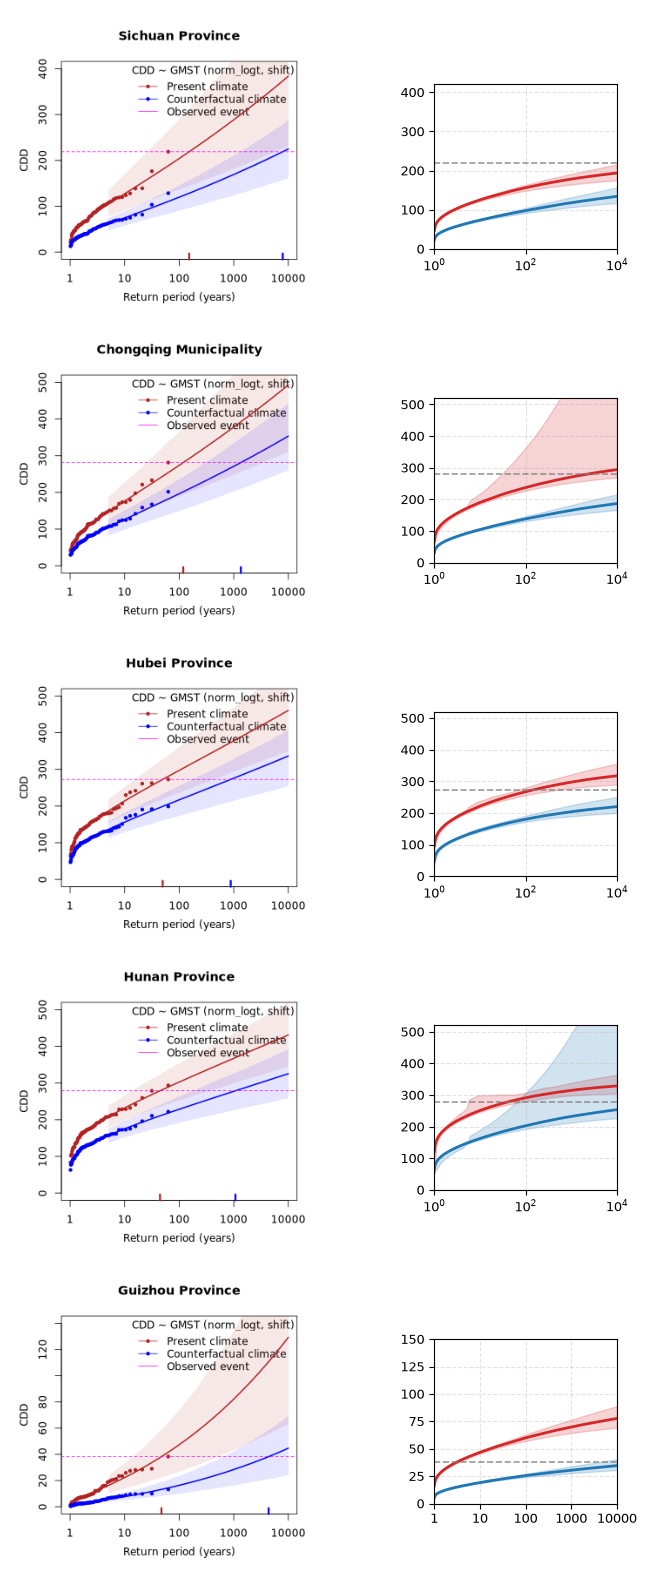

Saved figure to: /home/users/weijia_6/Yangtze_code/demand_result/five_province_m1_m2_returnperiod_comparison_BALANCED.png


In [20]:
# ============================================================
# Return period comparison — balanced left/right subfigure sizes
# ============================================================

from __future__ import annotations

from pathlib import Path
import glob
import pickle
import warnings

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# PATHS
# ============================================================

M1_IMAGE_DIR = Path("/home/users/weijia_6/Yangtze_code/method_1_result")
FIT_STORE_PATH = Path("/home/users/weijia_6/Yangtze_code/demand_result/fit_store_shared_family.pkl")

OUT_DIR = Path("/home/users/weijia_6/Yangtze_code/demand_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG = OUT_DIR / "five_province_m1_m2_returnperiod_comparison_BALANCED.png"
OUT_M2 = OUT_DIR / "m2_returnlevel_curves_summary_BALANCED.csv"

# ============================================================
# SETTINGS
# ============================================================

PROVINCES = [
    "Sichuan Province",
    "Chongqing Municipality",
    "Hubei Province",
    "Hunan Province",
    "Guizhou Province",
]

PROVINCE_SHORT = {
    "Sichuan Province": "Sichuan",
    "Chongqing Municipality": "Chongqing",
    "Hubei Province": "Hubei",
    "Hunan Province": "Hunan",
    "Guizhou Province": "Guizhou",
}

# Extend RP grid to 10,000
RP_MIN = 1.01
RP_MAX = 10000.0
N_RP = 400
RP_GRID = np.logspace(np.log10(RP_MIN), np.log10(RP_MAX), N_RP)

N_BOOT = 300
RANDOM_SEED = 42

FIGSIZE = (8, 16.0)
F_COLOR = "#d62728"
CF_COLOR = "#1f77b4"
ALPHA = 0.20
LW = 2.0

plt.rcParams.update({
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ============================================================
# LOAD FIT STORE
# ============================================================

with FIT_STORE_PATH.open("rb") as f:
    fit_store = pickle.load(f)

shared_families = {fit_store[p]["shared_family"] for p in PROVINCES}
SHARED_FAMILY = next(iter(shared_families))
dist_family = getattr(stats, SHARED_FAMILY)
rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# LOAD 2022 EVENT VALUES
# ============================================================

EVENT_CSV = "/home/users/weijia_6/Yangtze_code/popweighted_CDD_summer_sum_1961_2022_regridded_to_hadgem.csv"
df_event = pd.read_csv(EVENT_CSV, index_col=0)
df_event.index = df_event.index.str.strip()

event_2022 = {prov: float(df_event.loc[prov, "2022"]) for prov in PROVINCES}

# ============================================================
# HELPERS
# ============================================================

def clean_array(arr):
    arr = np.asarray(arr, dtype=float)
    return arr[np.isfinite(arr)]

def crop_white_margins(img, thresh=250):
    if img.ndim == 3:
        mask = np.any(img < thresh, axis=2)
    else:
        mask = img < thresh
    if not np.any(mask):
        return img
    ys, xs = np.where(mask)
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1]

def find_m1_image(province):
    patterns = [
        f"fit_model_returnperiod_{province}.png",
        f"fit_model_returnperiod_{province.replace(' ', '_')}.png",
        f"fit_model_returnperiod_{province.replace(' ', '')}.png",
        f"fit_model_returnperiod_{province}*.png",
        f"fit_model_returnperiod_{province.replace(' ', '_')}*.png",
        f"fit_model_returnperiod_{province.replace(' ', '')}*.png",
    ]
    for pat in patterns:
        matches = sorted(glob.glob(str(M1_IMAGE_DIR / pat)))
        if matches:
            return Path(matches[0])
    stem = province.replace(" Province", "").replace(" Municipality", "")
    matches = sorted(M1_IMAGE_DIR.glob(f"*{stem}*returnperiod*.png"))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"No M1 PNG for {province}")

def return_value_from_rp(dist, rp_grid):
    prob = 1.0 - 1.0 / rp_grid
    with np.errstate(over="ignore", under="ignore", divide="ignore", invalid="ignore"):
        return dist.ppf(prob)

def fit_shared_family(sample):
    sample = clean_array(sample)
    if sample.size < 10:
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        try:
            params = dist_family.fit(sample)
            dist = dist_family(*params)
        except Exception:
            return None
    params = np.asarray(params, float)
    if not np.all(np.isfinite(params)) or params[-1] <= 0:
        return None
    return dist

def summarise_bootstrap(arr):
    mid = np.nanpercentile(arr, 50, axis=0)
    lo = np.nanpercentile(arr, 2.5, axis=0)
    hi = np.nanpercentile(arr, 97.5, axis=0)
    return mid, lo, hi

def compute_m2_returnlevel_curves(province):
    factual_data = clean_array(fit_store[province]["factual"]["data"])
    counter_data = clean_array(fit_store[province]["counterfactual"]["data"])

    dist_f0 = fit_shared_family(factual_data)
    dist_cf0 = fit_shared_family(counter_data)

    factual_det = return_value_from_rp(dist_f0, RP_GRID)
    counter_det = return_value_from_rp(dist_cf0, RP_GRID)

    factual_boot = []
    counter_boot = []

    for _ in range(N_BOOT):
        sF = dist_f0.rvs(size=factual_data.size, random_state=rng)
        sCF = dist_cf0.rvs(size=counter_data.size, random_state=rng)
        dist_f = fit_shared_family(sF)
        dist_cf = fit_shared_family(sCF)
        if dist_f is None or dist_cf is None:
            continue
        factual_boot.append(return_value_from_rp(dist_f, RP_GRID))
        counter_boot.append(return_value_from_rp(dist_cf, RP_GRID))

    factual_boot = np.asarray(factual_boot)
    counter_boot = np.asarray(counter_boot)

    f_mid, f_lo, f_hi = summarise_bootstrap(factual_boot)
    cf_mid, cf_lo, cf_hi = summarise_bootstrap(counter_boot)

    return {
        "Province": province,
        "Return_period": RP_GRID,
        "factual_mid": f_mid,
        "factual_lo": f_lo,
        "factual_hi": f_hi,
        "counter_mid": cf_mid,
        "counter_lo": cf_lo,
        "counter_hi": cf_hi,
    }

def plot_m2_panel(ax, curve, province_short):
    rp = curve["Return_period"]

    ax.fill_between(rp, curve["factual_lo"], curve["factual_hi"], color=F_COLOR, alpha=ALPHA)
    ax.plot(rp, curve["factual_mid"], color=F_COLOR, lw=LW)

    ax.fill_between(rp, curve["counter_lo"], curve["counter_hi"], color=CF_COLOR, alpha=ALPHA)
    ax.plot(rp, curve["counter_mid"], color=CF_COLOR, lw=LW)

    ax.set_xscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

# ============================================================
# BUILD M2 CURVES
# ============================================================

m2_curve_store = {prov: compute_m2_returnlevel_curves(prov) for prov in PROVINCES}

# ============================================================
# CUSTOM Y‑LIMITS
# ============================================================

custom_y_limits = {
    "Sichuan Province": (0, 420),
    "Chongqing Municipality": (0, 520),
    "Hubei Province": (0, 520),
    "Hunan Province": (0, 520),
    "Guizhou Province": (0, 150),
}

# ============================================================
# FIGURE — Balanced shrink (width + height)
# ============================================================

fig, axes = plt.subplots(
    nrows=len(PROVINCES),
    ncols=2,
    figsize=FIGSIZE,
    gridspec_kw={"width_ratios": [1.0, 0.36]},   # <<< balanced width
)

# ============================================================
# MAIN LOOP
# ============================================================

for i, prov in enumerate(PROVINCES):

    # Left column: M1 PNG
    img_path = find_m1_image(prov)
    img = crop_white_margins(mpimg.imread(img_path))
    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")

    # Right column: M2 curves
    ax_m2 = axes[i, 1]
    ax_m2.set_box_aspect(0.9) # shrink height
    plot_m2_panel(ax_m2, m2_curve_store[prov], PROVINCE_SHORT[prov])

    # -------------------------------
    # APPLY CUSTOM Y‑LIMITS
    # -------------------------------
    ymin, ymax = custom_y_limits[prov]
    ax_m2.set_ylim(ymin, ymax)

    # -------------------------------
    # CUSTOM X‑LIMITS
    # -------------------------------
    ax_m2.set_xlim(1, 10000)

    # -------------------------------
    # ADD 2022 EVENT HORIZONTAL LINE
    # -------------------------------
    ax_m2.axhline(
        event_2022[prov],
        color="grey",
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
    )

    # -------------------------------
    # X‑ticks only on last row
    # -------------------------------
    # if i < len(PROVINCES) - 1:
    #     ax_m2.tick_params(labelbottom=False)
    # else:
    #     ax_m2.set_xlabel("Return period (years)")
    #     ax_m2.set_xticks([1, 10, 100, 1000, 10000])
    #     ax_m2.set_xticklabels(["1", "10", "100", "1000", "10000"])

    # X‑ticks only on last row (no x‑label)
    if i < len(PROVINCES) - 1:
        ax_m2.tick_params(labelbottom=True)
    else:
        ax_m2.set_xlabel("")   # remove x‑label
        ax_m2.set_xticks([1, 10, 100, 1000, 10000])
        ax_m2.set_xticklabels(["1", "10", "100", "1000", "10000"])

# ============================================================
# LAYOUT — Balanced shrink (height)
# ============================================================

# fig.subplots_adjust(
#     left=0.06,
#     right=0.94,
#     top=0.97,
#     bottom=0.04,
#     wspace=0.04,
#     hspace=0.22,   # <<< balanced height
# )

fig.subplots_adjust(
    left=0.06,
    right=0.94,
    top=0.99, # 0.97
    bottom=0.01, # 0.04
    wspace=0.04,
    hspace=0.001,   # <<< balanced height 0.22
)

plt.savefig(OUT_FIG, dpi=350, bbox_inches="tight")
plt.show()
plt.close()

print("Saved figure to:", OUT_FIG)
